# Modelo ConvLSTM para detección binaria y localización temporal usando `dx(t)`

Este cuaderno evalúa una arquitectura ConvLSTM aplicada a trayectorias sintéticas de difusión anómala con y sin punto de cambio, combinando detección binaria de la presencia de cambio y localización temporal de su posición a partir de la serie de incrementos `dx(t)`.

## Enfoque del cuaderno

Este cuaderno pertenece a la segunda fase experimental del proyecto, en la que se analizan trayectorias con y sin punto de cambio. La arquitectura ConvLSTM se introduce para estudiar si la combinación de convoluciones 1D y capas recurrentes mejora la caracterización de cambios locales en la serie de incrementos `dx(t)`.

El procedimiento conserva la misma estructura general de evaluación que los demás modelos: preparación de datos, entrenamiento, selección de umbral, evaluación global y análisis detallado por transición.


## 1. Configuración experimental

Se definen los parámetros generales de ejecución, las rutas de entrada y salida, las semillas aleatorias y las opciones que controlan el tamaño del experimento. El modo rápido permite comprobar el flujo completo con un subconjunto equilibrado, mientras que el modo global utiliza todas las trayectorias disponibles.

Para una ejecución exploratoria se mantiene `FAST_RUN = True` y `GLOBAL_RUN = False`. Una vez verificada la carga de datos, el entrenamiento, el guardado del modelo y la evaluación, puede activarse la ejecución global mediante `FAST_RUN = False` y `GLOBAL_RUN = True`.


In [1]:

import json
import random
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, losses, metrics, optimizers

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

FAST_RUN = False
GLOBAL_RUN = True
GLOBAL_SHORT_TEST = False
GLOBAL_SHORT_EPOCHS = 3


FAST_TRAIN_SIZE = 20_000
FAST_VAL_SIZE = 4_000
FAST_TEST_SIZE = 10_000

LENGTH = 100
DX_LENGTH = LENGTH - 1
MIN_SEGMENT_LENGTH = 20
VALID_DX_MIN = MIN_SEGMENT_LENGTH - 1
VALID_DX_MAX = LENGTH - MIN_SEGMENT_LENGTH - 1

MODEL_NAMES = ["ATTM", "CTRW", "FBM", "LW", "SBM"]
MODEL_MAP = {i: name for i, name in enumerate(MODEL_NAMES)}
TRANSITIONS = [(m1, m2) for m1 in MODEL_NAMES for m2 in MODEL_NAMES if m1 != m2]
TRANSITION_ORDER = [f"{m1} → {m2}" for m1, m2 in TRANSITIONS]

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data_synthetic_with_without_changepoint_dx"

OUTPUT_DIR = PROJECT_ROOT / "model_outputs" / (
    "convlstm_softonly_fast_test_detection_localization_dx" if FAST_RUN else "convlstm_softonly_global_detection_localization_dx"
)
FIGURES_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

BATCH_SIZE = 256
MAX_EPOCHS = GLOBAL_SHORT_EPOCHS if (GLOBAL_RUN and GLOBAL_SHORT_TEST) else (30 if FAST_RUN else 100)
LEARNING_RATE = 1e-3

# La détection reste importante, mais la localisation est renforcée par rapport au LSTM original.
LOSS_WEIGHTS = [2.0, 1.8]

# Pondération de la BCE pour pénaliser davantage les faux positifs.
NEGATIVE_CLASS_WEIGHT = 1.8
POSITIVE_CLASS_WEIGHT = 1.0

# Grille de seuils plus fine pour mieux contrôler le compromis recall/FPR.
THRESHOLDS = np.array([
    0.25, 0.28, 0.30, 0.32, 0.34, 0.35,
    0.36, 0.38, 0.40, 0.42, 0.45, 0.50,
], dtype=float)

MONITOR_METRIC = "val_selection_score"

DATA_FILES = {
    "train": DATA_DIR / f"train_L{LENGTH}_dim1_with_without_dx.h5",
    "val": DATA_DIR / f"val_L{LENGTH}_dim1_with_without_dx.h5",
    "test": DATA_DIR / f"test_L{LENGTH}_dim1_with_without_dx.h5",
}

if FAST_RUN == GLOBAL_RUN:
    raise ValueError("Choose exactly one mode: FAST_RUN=True or GLOBAL_RUN=True.")

pd.DataFrame({
    "item": [
        "FAST_RUN", "GLOBAL_RUN", "GLOBAL_SHORT_TEST", "OUTPUT_DIR", "BATCH_SIZE", "MAX_EPOCHS",
        "LOSS_WEIGHTS", "NEGATIVE_CLASS_WEIGHT", "POSITIVE_CLASS_WEIGHT", "THRESHOLDS",
    ],
    "value": [
        FAST_RUN, GLOBAL_RUN, GLOBAL_SHORT_TEST, str(OUTPUT_DIR), BATCH_SIZE, MAX_EPOCHS,
        str(LOSS_WEIGHTS), NEGATIVE_CLASS_WEIGHT, POSITIVE_CLASS_WEIGHT, str(THRESHOLDS.tolist()),
    ],
})


,item,value
0,FAST_RUN,False
1,GLOBAL_RUN,True
2,GLOBAL_SHORT_TEST,False
3,OUTPUT_DIR,C:\Users\chair\Downloads\changepoint_new_phase...
4,BATCH_SIZE,256
5,MAX_EPOCHS,100
6,LOSS_WEIGHTS,"[2.0, 1.8]"
7,NEGATIVE_CLASS_WEIGHT,1.8
8,POSITIVE_CLASS_WEIGHT,1.0
9,THRESHOLDS,"[0.25, 0.28, 0.3, 0.32, 0.34, 0.35, 0.36, 0.38..."


## 2. Carga de datos experimentales

Se leen las particiones HDF5 generadas en el cuaderno de construcción del conjunto sintético. En esta fase, la entrada utilizada por el modelo es `dx(t)`, por lo que la posición absoluta `x(t)` no se incorpora directamente al entrenamiento.

La comprobación inicial se limita a verificar la disponibilidad y coherencia básica de las variables necesarias, ya que la validación estructural del conjunto de datos se documenta en el cuaderno correspondiente.

In [2]:

def decode_model(value):
    if isinstance(value, bytes):
        text = value.decode("utf-8")
        return text
    if isinstance(value, str):
        return value
    return MODEL_MAP[int(value)]


def normalize_dx(dx):
    mean = dx.mean(axis=1, keepdims=True)
    std = dx.std(axis=1, keepdims=True)
    return (dx - mean) / np.maximum(std, 1e-6)


def load_split(split_name):
    file_path = DATA_FILES[split_name]
    if not file_path.exists():
        raise FileNotFoundError(f"Missing file: {file_path}")

    with h5py.File(file_path, "r") as file:
        dx = file["dx"][:].astype("float32")
        has_cp = file["has_changepoint"][:].astype("float32")
        cp = file["cp"][:].astype("int16")
        cp_dx = file["cp_dx"][:].astype("int16") if "cp_dx" in file else (cp - 1).astype("int16")
        model1 = file["model1"][:]
        model2 = file["model2"][:]

    if dx.ndim == 2:
        dx = dx[:, :, None]

    dx = normalize_dx(dx).astype("float32")
    cp_class = np.where(has_cp == 1, cp_dx, 0).astype("int32")

    metadata = pd.DataFrame({
        "split": split_name,
        "has_changepoint": has_cp.astype(int),
        "cp": cp,
        "cp_dx": cp_dx,
        "cp_class": cp_class,
        "model1": [decode_model(value) for value in model1],
        "model2": [decode_model(value) for value in model2],
    })

    metadata["transition"] = np.where(
        metadata["has_changepoint"] == 1,
        metadata["model1"] + " → " + metadata["model2"],
        metadata["model1"] + " (no changepoint)",
    )

    return dx, has_cp.reshape(-1, 1).astype("float32"), cp_class.astype("int32"), metadata


x_train_full, y_has_train_full, y_cp_train_full, train_metadata_full = load_split("train")
x_val_full, y_has_val_full, y_cp_val_full, val_metadata_full = load_split("val")
x_test_full, y_has_test_full, y_cp_test_full, test_metadata_full = load_split("test")

pd.DataFrame({
    "split": ["train", "validation", "test"],
    "n_examples": [len(x_train_full), len(x_val_full), len(x_test_full)],
    "dx_shape": [x_train_full.shape[1:], x_val_full.shape[1:], x_test_full.shape[1:]],
})


,split,n_examples,dx_shape
0,train,200000,"(99, 1)"
1,validation,20000,"(99, 1)"
2,test,200000,"(99, 1)"


## 3. Selección del régimen de ejecución

El modo rápido selecciona un subconjunto equilibrado de trayectorias con y sin punto de cambio para validar la ejecución completa del cuaderno. El modo global emplea cada partición en su totalidad y se reserva para la evaluación experimental final.

Esta separación permite distinguir entre una comprobación funcional del procedimiento y el entrenamiento completo destinado a producir resultados comparables entre arquitecturas.


In [3]:

def balanced_subset(x, y_has, y_cp_class, metadata, n_total, seed):
    rng = np.random.default_rng(seed)
    n_with = n_total // 2
    n_without = n_total - n_with

    with_meta = metadata[metadata["has_changepoint"] == 1]
    without_meta = metadata[metadata["has_changepoint"] == 0]

    selected = []

    per_transition = n_with // len(TRANSITION_ORDER)
    extra_transition = n_with % len(TRANSITION_ORDER)

    for i, transition in enumerate(TRANSITION_ORDER):
        group = with_meta[with_meta["transition"] == transition].index.to_numpy()
        k = per_transition + (1 if i < extra_transition else 0)
        selected.extend(rng.choice(group, size=min(k, len(group)), replace=False))

    per_model = n_without // len(MODEL_NAMES)
    extra_model = n_without % len(MODEL_NAMES)

    for i, model_name in enumerate(MODEL_NAMES):
        group = without_meta[without_meta["model1"] == model_name].index.to_numpy()
        k = per_model + (1 if i < extra_model else 0)
        selected.extend(rng.choice(group, size=min(k, len(group)), replace=False))

    selected = np.array(selected, dtype=int)
    rng.shuffle(selected)

    return (
        x[selected],
        y_has[selected],
        y_cp_class[selected],
        metadata.loc[selected].reset_index(drop=True),
    )


if FAST_RUN:
    x_train, y_has_train, y_cp_train, train_metadata = balanced_subset(
        x_train_full, y_has_train_full, y_cp_train_full, train_metadata_full, FAST_TRAIN_SIZE, RANDOM_SEED
    )
    x_val, y_has_val, y_cp_val, val_metadata = balanced_subset(
        x_val_full, y_has_val_full, y_cp_val_full, val_metadata_full, FAST_VAL_SIZE, RANDOM_SEED + 1
    )
    x_test, y_has_test, y_cp_test, test_metadata = balanced_subset(
        x_test_full, y_has_test_full, y_cp_test_full, test_metadata_full, FAST_TEST_SIZE, RANDOM_SEED + 2
    )
else:
    x_train, y_has_train, y_cp_train, train_metadata = x_train_full, y_has_train_full, y_cp_train_full, train_metadata_full
    x_val, y_has_val, y_cp_val, val_metadata = x_val_full, y_has_val_full, y_cp_val_full, val_metadata_full
    x_test, y_has_test, y_cp_test, test_metadata = x_test_full, y_has_test_full, y_cp_test_full, test_metadata_full

summary_rows = []
for name, x, y_has, metadata in [
    ("train", x_train, y_has_train, train_metadata),
    ("validation", x_val, y_has_val, val_metadata),
    ("test", x_test, y_has_test, test_metadata),
]:
    counts = metadata["has_changepoint"].value_counts().sort_index()
    summary_rows.append({
        "split": name,
        "n_examples": len(x),
        "dx_shape": x.shape[1:],
        "no_changepoint": int(counts.get(0, 0)),
        "changepoint": int(counts.get(1, 0)),
        "n_available_transitions": int(metadata[metadata["has_changepoint"] == 1]["transition"].nunique()),
    })

pd.DataFrame(summary_rows)


,split,n_examples,dx_shape,no_changepoint,changepoint,n_available_transitions
0,train,200000,"(99, 1)",100000,100000,20
1,validation,20000,"(99, 1)",10000,10000,20
2,test,200000,"(99, 1)",100000,100000,20


## 3.1 Aleatorización reproducible del conjunto de entrenamiento

El conjunto de entrenamiento puede estar organizado por bloques según la clase o el modelo de difusión. Si los lotes sucesivos son demasiado homogéneos, el proceso de optimización puede verse sesgado aunque el equilibrio global sea correcto.

Para evitarlo, se aplica una permutación aleatoria reproducible únicamente sobre el conjunto de entrenamiento antes de construir el objeto `tf.data.Dataset`. Las particiones de validación y test se mantienen sin mezclar para conservar una evaluación estable y comparable.

In [4]:

rng = np.random.default_rng(RANDOM_SEED)
train_permutation = rng.permutation(len(x_train))

x_train = x_train[train_permutation]
y_has_train = y_has_train[train_permutation]
y_cp_train = y_cp_train[train_permutation]
train_metadata = train_metadata.iloc[train_permutation].reset_index(drop=True)

print("Global train label distribution after shuffle:")
print(pd.Series(y_has_train.reshape(-1)).value_counts())

print("First 20k train labels after shuffle:")
print(pd.Series(y_has_train[:20000].reshape(-1)).value_counts())

print("Middle 20k train labels after shuffle:")
mid = len(y_has_train) // 2
print(pd.Series(y_has_train[mid:mid+20000].reshape(-1)).value_counts())

print("Last 20k train labels after shuffle:")
print(pd.Series(y_has_train[-20000:].reshape(-1)).value_counts())


Global train label distribution after shuffle:
0.0    100000
1.0    100000
Name: count, dtype: int64
First 20k train labels after shuffle:
0.0    10105
1.0     9895
Name: count, dtype: int64
Middle 20k train labels after shuffle:
0.0    10014
1.0     9986
Name: count, dtype: int64
Last 20k train labels after shuffle:
1.0    10017
0.0     9983
Name: count, dtype: int64


## 4. Definición de etiquetas y ponderación de pérdidas

La salida `has_cp` se define para todas las trayectorias y permite entrenar la detección binaria. La salida `cp_dist` solo tiene significado físico cuando existe un punto de cambio real, por lo que la pérdida de localización se pondera con valor cero en las trayectorias sin punto de cambio.

Esta formulación evita imponer una posición artificial a trayectorias homogéneas y separa explícitamente el aprendizaje de la presencia del cambio de la estimación de su ubicación temporal.


In [5]:

def make_sample_weights(y_has):
    y_flat = y_has.reshape(-1).astype("float32")
    return (
        np.ones_like(y_flat, dtype="float32"),
        y_flat.astype("float32"),
    )


def make_dataset(x, y_has, y_cp_class, training=False):
    y = (
        y_has.astype("float32"),
        y_cp_class.astype("int32"),
    )
    sample_weight = make_sample_weights(y_has)
    dataset = tf.data.Dataset.from_tensor_slices((x, y, sample_weight))
    if training:
        dataset = dataset.shuffle(min(10_000, len(x)), seed=RANDOM_SEED, reshuffle_each_iteration=True)
    return dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


train_ds = make_dataset(x_train, y_has_train, y_cp_train, training=True)
val_ds = make_dataset(x_val, y_has_val, y_cp_val, training=False)
test_ds = make_dataset(x_test, y_has_test, y_cp_test, training=False)

print("Datasets ready.")
print("Output order: [has_cp, cp_dist]")


Datasets ready.
Output order: [has_cp, cp_dist]


## 5. Arquitectura ConvLSTM adaptada a `dx(t)`

El modelo utiliza un bloque convolucional 1D para extraer patrones locales en la serie de incrementos antes de aplicar capas LSTM. Las convoluciones permiten detectar variaciones de escala corta asociadas a cambios de régimen, mientras que las capas recurrentes integran información temporal a lo largo de la secuencia.

La red mantiene dos salidas: `has_cp` para la detección binaria y `cp_dist` para la localización temporal del punto de cambio.

In [6]:

@tf.keras.utils.register_keras_serializable(package="Changepoint")
class ValidPositionMask(layers.Layer):
    def __init__(self, sequence_length, valid_min, valid_max, **kwargs):
        super().__init__(**kwargs)
        self.sequence_length = int(sequence_length)
        self.valid_min = int(valid_min)
        self.valid_max = int(valid_max)

    def call(self, logits):
        positions = tf.range(self.sequence_length)
        valid = tf.logical_and(positions >= self.valid_min, positions <= self.valid_max)
        valid = tf.cast(valid, tf.float32)
        mask = (1.0 - valid) * (-1e9)
        return logits + mask[tf.newaxis, :]

    def get_config(self):
        config = super().get_config()
        config.update({
            "sequence_length": self.sequence_length,
            "valid_min": self.valid_min,
            "valid_max": self.valid_max,
        })
        return config


@tf.keras.utils.register_keras_serializable(package="Changepoint")
class LastStep(layers.Layer):
    def call(self, inputs):
        return inputs[:, -1, :]


@tf.keras.utils.register_keras_serializable(package="Changepoint")
class SqueezeLastAxis(layers.Layer):
    def call(self, inputs):
        return tf.squeeze(inputs, axis=-1)


@tf.keras.utils.register_keras_serializable(package="Changepoint")
def sparse_ce_localization(y_true, y_pred):
    y_true = tf.reshape(tf.cast(y_true, tf.int32), [-1])
    n_positions = tf.shape(y_pred)[1]
    y_true = tf.clip_by_value(y_true, 0, n_positions - 1)
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
    batch_size = tf.shape(y_pred)[0]
    gather_indices = tf.stack([tf.range(batch_size, dtype=tf.int32), y_true], axis=1)
    true_prob = tf.gather_nd(y_pred, gather_indices)
    return -tf.math.log(true_prob)


@tf.keras.utils.register_keras_serializable(package="Changepoint")
def weighted_binary_crossentropy_no_cp(y_true, y_pred):
    """Binary cross-entropy pondérée pour réduire les faux positifs.

    Les exemples sans changepoint reçoivent un poids plus élevé. Cela pousse le modèle
    à être moins sensible aux fluctuations naturelles des trajectoires homogènes.
    """
    y_true = tf.reshape(tf.cast(y_true, tf.float32), [-1])
    y_pred = tf.reshape(tf.cast(y_pred, tf.float32), [-1])
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

    positive_loss = -POSITIVE_CLASS_WEIGHT * y_true * tf.math.log(y_pred)
    negative_loss = -NEGATIVE_CLASS_WEIGHT * (1.0 - y_true) * tf.math.log(1.0 - y_pred)
    return positive_loss + negative_loss


def conv_residual_block(x, filters, kernel_size=5, dilation_rate=1, dropout=0.10, name="conv_block"):
    shortcut = x
    if x.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, kernel_size=1, padding="same", name=f"{name}_shortcut")(shortcut)

    y = layers.Conv1D(
        filters,
        kernel_size=kernel_size,
        padding="same",
        dilation_rate=dilation_rate,
        name=f"{name}_conv_1",
    )(x)
    y = layers.LayerNormalization(name=f"{name}_norm_1")(y)
    y = layers.Activation("gelu", name=f"{name}_gelu_1")(y)
    y = layers.SpatialDropout1D(dropout, name=f"{name}_spatial_dropout")(y)

    y = layers.Conv1D(
        filters,
        kernel_size=kernel_size,
        padding="same",
        dilation_rate=dilation_rate,
        name=f"{name}_conv_2",
    )(y)
    y = layers.LayerNormalization(name=f"{name}_norm_2")(y)

    y = layers.Add(name=f"{name}_residual_add")([shortcut, y])
    y = layers.Activation("gelu", name=f"{name}_output_gelu")(y)
    return y


def build_convlstm_model(input_shape=(DX_LENGTH, 1)):
    inputs = layers.Input(shape=input_shape, name="dx_input")

    # Extracteur local pour détecter les ruptures dans dx(t).
    x = layers.Conv1D(64, kernel_size=5, padding="same", name="conv_stem_1")(inputs)
    x = layers.LayerNormalization(name="conv_stem_norm_1")(x)
    x = layers.Activation("gelu", name="conv_stem_gelu_1")(x)
    x = layers.SpatialDropout1D(0.10, name="conv_stem_dropout_1")(x)

    x = layers.Conv1D(96, kernel_size=5, padding="same", name="conv_stem_2")(x)
    x = layers.LayerNormalization(name="conv_stem_norm_2")(x)
    x = layers.Activation("gelu", name="conv_stem_gelu_2")(x)

    # Blocs résiduels dilatés pour capter des motifs locaux à plusieurs échelles.
    x = conv_residual_block(x, 96, kernel_size=5, dilation_rate=1, dropout=0.10, name="conv_res_block_d1")
    x = conv_residual_block(x, 96, kernel_size=5, dilation_rate=2, dropout=0.10, name="conv_res_block_d2")
    x = conv_residual_block(x, 96, kernel_size=5, dilation_rate=4, dropout=0.10, name="conv_res_block_d4")

    # Modélisation temporelle globale.
    x = layers.LSTM(128, return_sequences=True, dropout=0.15, name="lstm_1")(x)
    x = layers.LayerNormalization(name="lstm_norm_1")(x)

    x = layers.LSTM(96, return_sequences=True, dropout=0.10, name="lstm_2")(x)
    x = layers.LayerNormalization(name="lstm_norm_2")(x)

    avg_pool = layers.GlobalAveragePooling1D(name="average_pooling")(x)
    max_pool = layers.GlobalMaxPooling1D(name="max_pooling")(x)
    last_state = LastStep(name="last_state")(x)

    det = layers.Concatenate(name="detection_features")([avg_pool, max_pool, last_state])
    det = layers.Dense(128, activation="gelu", name="detection_dense_1")(det)
    det = layers.Dropout(0.25, name="detection_dropout_1")(det)
    det = layers.Dense(64, activation="gelu", name="detection_dense_2")(det)
    det = layers.Dropout(0.10, name="detection_dropout_2")(det)
    has_cp = layers.Dense(1, activation="sigmoid", name="has_cp")(det)

    loc = layers.TimeDistributed(layers.Dense(128, activation="gelu"), name="localization_dense_1")(x)
    loc = layers.Dropout(0.15, name="localization_dropout_1")(loc)
    loc = layers.TimeDistributed(layers.Dense(64, activation="gelu"), name="localization_dense_2")(loc)
    loc = layers.Dropout(0.10, name="localization_dropout_2")(loc)
    logits = layers.TimeDistributed(layers.Dense(1), name="localization_logits_td")(loc)
    logits = SqueezeLastAxis(name="localization_logits")(logits)
    logits = ValidPositionMask(DX_LENGTH, VALID_DX_MIN, VALID_DX_MAX, name="valid_position_mask")(logits)
    cp_dist = layers.Activation("softmax", name="cp_dist")(logits)

    return models.Model(inputs=inputs, outputs=[has_cp, cp_dist], name="convlstm_softonly_detection_localization_dx")


model = build_convlstm_model(input_shape=(DX_LENGTH, 1))

model.compile(
    optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=[
        weighted_binary_crossentropy_no_cp,
        sparse_ce_localization,
    ],
    loss_weights=LOSS_WEIGHTS,
    metrics=[
        [
            metrics.BinaryAccuracy(name="accuracy"),
            metrics.Precision(name="precision"),
            metrics.Recall(name="recall"),
        ],
        [
            metrics.SparseCategoricalAccuracy(name="sparse_accuracy"),
        ],
    ],
)

model.summary()


Model: "convlstm_softonly_detection_localization_dx"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ dx_input (InputLayer)         │ (None, 99, 1)             │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_stem_1 (Conv1D)          │ (None, 99, 64)            │             384 │ dx_input[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_stem_norm_1              │ (None, 99, 64)            │             128 │ conv_stem_1[0][0]          │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_stem_gelu_1 (Activation) │ (None, 99, 64)            │               0 │ conv_stem_norm_1[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_stem_dropout_1           │ (None, 99, 64)            │               0 │ conv_stem_gelu_1[0][0]     │
│ (SpatialDropout1D)            │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_stem_2 (Conv1D)          │ (None, 99, 96)            │          30,816 │ conv_stem_dropout_1[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_stem_norm_2              │ (None, 99, 96)            │             192 │ conv_stem_2[0][0]          │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_stem_gelu_2 (Activation) │ (None, 99, 96)            │               0 │ conv_stem_norm_2[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_res_block_d1_conv_1      │ (None, 99, 96)            │          46,176 │ conv_stem_gelu_2[0][0]     │
│ (Conv1D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_res_block_d1_norm_1      │ (None, 99, 96)            │             192 │ conv_res_block_d1_conv_1[… │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_res_block_d1_gelu_1      │ (None, 99, 96)            │               0 │ conv_res_block_d1_norm_1[… │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_res_block_d1_spatial_dr… │ (None, 99, 96)            │               0 │ conv_res_block_d1_gelu_1[… │
│ (SpatialDropout1D)            │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_res_block_d1_conv_2      │ (None, 99, 96)            │          46,176 │ conv_res_block_d1_spatial… │
│ (Conv1D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 577,826 (2.20 MB)

 Trainable params: 577,826 (2.20 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Métricas de validación y selección del umbral

Durante el entrenamiento se calcula un criterio de validación que combina calidad de detección, control de falsos positivos y precisión de localización. La posición estimada se deriva de la distribución `cp_dist`, lo que mantiene una definición homogénea de la localización temporal entre arquitecturas.

El umbral de detección se selecciona sobre validación para equilibrar la sensibilidad ante trayectorias con punto de cambio y la estabilidad frente a trayectorias homogéneas.

In [7]:
def unpack_predictions(predictions):
    if isinstance(predictions, (list, tuple)):
        return predictions[0], predictions[1]
    return predictions["has_cp"], predictions["cp_dist"]


def detection_metrics(y_true, probabilities, threshold):
    y_true = np.asarray(y_true).reshape(-1).astype(int)
    probabilities = np.asarray(probabilities).reshape(-1)
    y_pred = (probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    return {
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1_score": float(f1_score(y_true, y_pred, zero_division=0)),
        "false_positive_rate": float(fp / (fp + tn + 1e-8)),
        "false_negative_rate": float(fn / (fn + tp + 1e-8)),
        "jaccard_coefficient": float(tp / (tp + fp + fn + 1e-8)),
        "true_negatives": int(tn),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "true_positives": int(tp),
    }


def soft_positions(cp_dist):
    positions = np.arange(cp_dist.shape[1], dtype=np.float32)
    return np.sum(cp_dist * positions.reshape(1, -1), axis=1) + 1.0


def localization_metrics(metadata, probabilities, cp_dist, threshold):
    y_true_has = metadata["has_changepoint"].to_numpy(dtype=int)
    y_pred_has = (np.asarray(probabilities).reshape(-1) >= threshold).astype(int)
    pred_cp = soft_positions(cp_dist)

    mask_all = y_true_has == 1
    mask_tp = (y_true_has == 1) & (y_pred_has == 1)

    def compute(mask, prefix):
        if int(mask.sum()) == 0:
            return {f"{prefix}_n": 0, f"{prefix}_mae": np.nan, f"{prefix}_rmse": np.nan}
        true_cp = metadata.loc[mask, "cp"].to_numpy(dtype=np.float32)
        return {
            f"{prefix}_n": int(mask.sum()),
            f"{prefix}_mae": float(mean_absolute_error(true_cp, pred_cp[mask])),
            f"{prefix}_rmse": float(np.sqrt(mean_squared_error(true_cp, pred_cp[mask]))),
        }

    values = {}
    values.update(compute(mask_all, "all_changepoint"))
    values.update(compute(mask_tp, "true_positive"))
    return values


def threshold_table(y_true, probabilities, cp_dist, metadata, thresholds=THRESHOLDS):
    rows = []
    for threshold in thresholds:
        row = detection_metrics(y_true, probabilities, threshold)
        row.update(localization_metrics(metadata, probabilities, cp_dist, threshold))
        rows.append(row)
    return pd.DataFrame(rows)


def choose_threshold(table):
    # Priorité : garder un recall utile tout en contrôlant les faux positifs.
    candidates = table[(table["recall"] >= 0.65) & (table["false_positive_rate"] <= 0.25)].copy()
    if candidates.empty:
        candidates = table[(table["recall"] >= 0.65) & (table["false_positive_rate"] <= 0.30)].copy()
    if candidates.empty:
        candidates = table[table["recall"] >= 0.65].copy()
    if candidates.empty:
        candidates = table.copy()
    candidates = candidates.sort_values(
        ["f1_score", "false_positive_rate", "true_positive_rmse", "precision"],
        ascending=[False, True, True, False],
    )
    return candidates.iloc[0].to_dict()


class ValidationMetricsCallback(callbacks.Callback):
    def __init__(self, x_val, y_has_val, val_metadata, batch_size=2048):
        super().__init__()
        self.x_val = x_val
        self.y_has_val = y_has_val.reshape(-1).astype(int)
        self.val_metadata = val_metadata.reset_index(drop=True)
        self.batch_size = batch_size
        self.records = []
        self.threshold_records = []

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        has_prob, cp_dist = unpack_predictions(self.model.predict(self.x_val, batch_size=self.batch_size, verbose=0))
        has_prob = has_prob.reshape(-1)
        cp_dist = np.asarray(cp_dist)

        table = threshold_table(self.y_has_val, has_prob, cp_dist, self.val_metadata, THRESHOLDS)
        best = choose_threshold(table)

        # Score de sélection : localisation soft + détection + pénalité sur faux positifs/faux négatifs.
        score = (
            best["true_positive_rmse"]
            + 15.0 * (1.0 - best["f1_score"])
            + 8.0 * best["false_positive_rate"]
            + 4.0 * best["false_negative_rate"]
        )

        record = {
            "epoch": epoch + 1,
            "val_best_threshold": float(best["threshold"]),
            "val_detection_accuracy": float(best["accuracy"]),
            "val_detection_precision": float(best["precision"]),
            "val_detection_recall": float(best["recall"]),
            "val_detection_f1": float(best["f1_score"]),
            "val_false_positive_rate": float(best["false_positive_rate"]),
            "val_false_negative_rate": float(best["false_negative_rate"]),
            "val_jaccard_coefficient": float(best["jaccard_coefficient"]),
            "val_localization_mae_all_cp": float(best["all_changepoint_mae"]),
            "val_localization_rmse_all_cp": float(best["all_changepoint_rmse"]),
            "val_localization_mae_true_positive": float(best["true_positive_mae"]),
            "val_localization_rmse_true_positive": float(best["true_positive_rmse"]),
            "val_selection_score": float(score),
        }

        self.records.append(record)
        table["epoch"] = epoch + 1
        self.threshold_records.append(table)
        logs.update({k: v for k, v in record.items() if k != "epoch"})

        print(
            f"\nval_threshold={record['val_best_threshold']:.2f} | "
            f"F1={record['val_detection_f1']:.4f} | "
            f"recall={record['val_detection_recall']:.4f} | "
            f"FPR={record['val_false_positive_rate']:.4f} | "
            f"RMSE_TP={record['val_localization_rmse_true_positive']:.2f}"
        )


val_metrics_callback = ValidationMetricsCallback(x_val, y_has_val, val_metadata)

## 7. Estrategia de entrenamiento y almacenamiento local

El entrenamiento utiliza mecanismos de seguimiento para registrar métricas, conservar el mejor modelo, ajustar la tasa de aprendizaje y detener la optimización cuando sea necesario. Los resultados se almacenan en un directorio local específico para esta arquitectura, evitando sobrescribir salidas de otros modelos.

Los artefactos generados durante el entrenamiento deben mantenerse fuera del repositorio, de modo que GitHub contenga únicamente el cuaderno, el código y las instrucciones necesarias para reproducir el experimento.

In [8]:

checkpoint_path = OUTPUT_DIR / "best_convlstm_softonly_detection_localization_dx.keras"
training_log_path = OUTPUT_DIR / "training_log_convlstm_softonly_detection_localization_dx.csv"

training_callbacks = [
    val_metrics_callback,
    callbacks.ModelCheckpoint(
        checkpoint_path,
        monitor=MONITOR_METRIC,
        mode="min",
        save_best_only=True,
        verbose=1,
    ),
    callbacks.EarlyStopping(
        monitor=MONITOR_METRIC,
        patience=8 if FAST_RUN else 15,
        mode="min",
        restore_best_weights=True,
        verbose=1,
    ),
    callbacks.ReduceLROnPlateau(
        monitor=MONITOR_METRIC,
        factor=0.5,
        patience=4 if FAST_RUN else 6,
        mode="min",
        min_lr=1e-6,
        verbose=1,
    ),
    callbacks.CSVLogger(training_log_path),
]

print("Active mode:", "FAST_RUN" if FAST_RUN else "GLOBAL_RUN")
print("Global short test:", GLOBAL_SHORT_TEST)
print("Output directory:", OUTPUT_DIR)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=MAX_EPOCHS,
    callbacks=training_callbacks,
    verbose=1,
)


Active mode: GLOBAL_RUN
Global short test: False
Output directory: C:\Users\chair\Downloads\changepoint_new_phase_files\model_outputs\convlstm_softonly_global_detection_localization_dx
Epoch 1/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - cp_dist_loss: 1.9565 - cp_dist_sparse_accuracy: 0.0334 - has_cp_accuracy: 0.5210 - has_cp_loss: 0.9083 - has_cp_precision: 0.6660 - has_cp_recall: 0.0680 - loss: 5.3384   
val_threshold=0.40 | F1=0.6936 | recall=0.6534 | FPR=0.2306 | RMSE_TP=12.30

Epoch 1: val_selection_score improved from None to 20.13138, saving model to C:\Users\chair\Downloads\changepoint_new_phase_files\model_outputs\convlstm_softonly_global_detection_localization_dx\best_convlstm_softonly_detection_localization_dx.keras

Epoch 1: finished saving model to C:\Users\chair\Downloads\changepoint_new_phase_files\model_outputs\convlstm_softonly_global_detection_localization_dx\best_convlstm_softonly_detection_localization_dx.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 2194s 3s/step - cp_dist_l

## 8. Evaluación posterior al entrenamiento

Tras el entrenamiento se recarga el mejor modelo según el rendimiento de validación. A partir de la partición de validación se selecciona el umbral de decisión, y las métricas finales se calculan sobre el conjunto de test.

La localización temporal se estima a partir de la distribución `cp_dist`, lo que permite evaluar de forma conjunta la detección binaria y la estimación de la posición del punto de cambio.

In [9]:

history_frame = pd.DataFrame(history.history)
validation_metrics_frame = pd.DataFrame(val_metrics_callback.records)
threshold_history_frame = pd.concat(val_metrics_callback.threshold_records, ignore_index=True)

history_frame.to_csv(OUTPUT_DIR / "history_convlstm_softonly_detection_localization_dx.csv", index=False)
validation_metrics_frame.to_csv(OUTPUT_DIR / "validation_metrics_convlstm_softonly_detection_localization_dx.csv", index=False)
threshold_history_frame.to_csv(OUTPUT_DIR / "threshold_history_convlstm_softonly_detection_localization_dx.csv", index=False)

best_model = tf.keras.models.load_model(
    checkpoint_path,
    custom_objects={
        "ValidPositionMask": ValidPositionMask,
        "LastStep": LastStep,
        "SqueezeLastAxis": SqueezeLastAxis,
        "sparse_ce_localization": sparse_ce_localization,
        "weighted_binary_crossentropy_no_cp": weighted_binary_crossentropy_no_cp,
    },
    compile=False,
    safe_mode=False,
)


def predict_outputs(model_to_use, x):
    has_prob, cp_dist = unpack_predictions(model_to_use.predict(x, batch_size=BATCH_SIZE, verbose=1))
    return np.asarray(has_prob).reshape(-1), np.asarray(cp_dist)


val_has_prob, val_cp_dist = predict_outputs(best_model, x_val)
test_has_prob, test_cp_dist = predict_outputs(best_model, x_test)

validation_threshold_table = threshold_table(y_has_val, val_has_prob, val_cp_dist, val_metadata, THRESHOLDS)
test_threshold_table = threshold_table(y_has_test, test_has_prob, test_cp_dist, test_metadata, THRESHOLDS)

selected_threshold = float(choose_threshold(validation_threshold_table)["threshold"])
validation_threshold_table["selected"] = validation_threshold_table["threshold"] == selected_threshold
test_threshold_table["selected"] = test_threshold_table["threshold"] == selected_threshold

validation_threshold_table.to_csv(OUTPUT_DIR / "threshold_comparison_validation.csv", index=False)
test_threshold_table.to_csv(OUTPUT_DIR / "threshold_comparison_test.csv", index=False)

print("Threshold Comparison for Changepoint Detection — Validation")
display(validation_threshold_table)

print("Threshold Comparison for Changepoint Detection — Test")
display(test_threshold_table)

print("Selected threshold:", selected_threshold)


79/79 ━━━━━━━━━━━━━━━━━━━━ 68s 814ms/step 
782/782 ━━━━━━━━━━━━━━━━━━━━ 607s 776ms/step
Threshold Comparison for Changepoint Detection — Validation


,threshold,accuracy,precision,recall,f1_score,false_positive_rate,false_negative_rate,jaccard_coefficient,true_negatives,false_positives,false_negatives,true_positives,all_changepoint_n,all_changepoint_mae,all_changepoint_rmse,true_positive_n,true_positive_mae,true_positive_rmse,selected
0,0.25,0.79055,0.801432,0.7725,0.786700,0.1914,0.2275,0.648397,8086,1914,2275,7725,10000,7.759906,12.052364,7725,5.959545,10.056348,True
1,0.28,0.79260,0.820974,0.7484,0.783009,0.1632,0.2516,0.643398,8368,1632,2516,7484,10000,7.759906,12.052364,7484,5.700700,9.734812,False
2,0.30,0.79215,0.831424,0.7329,0.779059,0.1486,0.2671,0.638081,8514,1486,2671,7329,10000,7.759906,12.052364,7329,5.551674,9.555986,False
3,0.32,0.79145,0.840837,0.7190,0.775160,0.1361,0.2810,0.632867,8639,1361,2810,7190,10000,7.759906,12.052364,7190,5.416016,9.385017,False
4,0.34,0.79090,0.850229,0.7062,0.771550,0.1244,0.2938,0.628068,8756,1244,2938,7062,10000,7.759906,12.052364,7062,5.275931,9.200534,False
5,0.35,0.79005,0.854108,0.6996,0.769172,0.1195,0.3004,0.624922,8805,1195,3004,6996,10000,7.759906,12.052364,6996,5.205959,9.120808,False
6,0.36,0.78975,0.858646,0.6937,0.767410,0.1142,0.3063,0.622599,8858,1142,3063,6937,10000,7.759906,12.052364,6937,5.157002,9.065328,False
7,0.38,0.78900,0.868905,0.6807,0.763373,0.1027,0.3193,0.617303,8973,1027,3193,6807,10000,7.759906,12.052364,6807,5.006848,8.850395,False
8,0.40,0.78765,0.876653,0.6695,0.759199,0.0942,0.3305,0.611863,9058,942,3305,6695,10000,7.759906,12.052364,6695,4.879316,8.675991,False
9,0.42,0.78565,0.883268,0.6583,0.754369,0.0870,0.3417,0.605612,9130,870,3417,6583,10000,7.759906,12.052364,6583,4.761529,8.521175,False


Threshold Comparison for Changepoint Detection — Test


,threshold,accuracy,precision,recall,f1_score,false_positive_rate,false_negative_rate,jaccard_coefficient,true_negatives,false_positives,false_negatives,true_positives,all_changepoint_n,all_changepoint_mae,all_changepoint_rmse,true_positive_n,true_positive_mae,true_positive_rmse,selected
0,0.25,0.789130,0.797980,0.77428,0.785951,0.19602,0.22572,0.647380,80398,19602,22572,77428,100000,7.66448,11.918347,77428,5.913591,9.951909,True
1,0.28,0.790375,0.816488,0.74912,0.781355,0.16837,0.25088,0.641167,83163,16837,25088,74912,100000,7.66448,11.918347,74912,5.664205,9.650409,False
2,0.30,0.790555,0.827862,0.73366,0.777920,0.15255,0.26634,0.636554,84745,15255,26634,73366,100000,7.66448,11.918347,73366,5.512105,9.470699,False
3,0.32,0.790335,0.838390,0.71933,0.774310,0.13866,0.28067,0.631734,86134,13866,28067,71933,100000,7.66448,11.918347,71933,5.371299,9.300879,False
4,0.34,0.790045,0.848398,0.70630,0.770855,0.12621,0.29370,0.627148,87379,12621,29370,70630,100000,7.66448,11.918347,70630,5.238852,9.137099,False
5,0.35,0.789535,0.852666,0.70003,0.768846,0.12096,0.29997,0.624492,87904,12096,29997,70003,100000,7.66448,11.918347,70003,5.173875,9.056693,False
6,0.36,0.789405,0.857206,0.69450,0.767323,0.11569,0.30550,0.622485,88431,11569,30550,69450,100000,7.66448,11.918347,69450,5.115287,8.979567,False
7,0.38,0.788060,0.865067,0.68259,0.763071,0.10647,0.31741,0.616908,89353,10647,31741,68259,100000,7.66448,11.918347,68259,4.987984,8.814443,False
8,0.40,0.787085,0.872998,0.67192,0.759373,0.09775,0.32808,0.612088,90225,9775,32808,67192,100000,7.66448,11.918347,67192,4.874222,8.663866,False
9,0.42,0.785995,0.880459,0.66185,0.755662,0.08986,0.33815,0.607280,91014,8986,33815,66185,100000,7.66448,11.918347,66185,4.772410,8.536058,False


Selected threshold: 0.25


## 9. Métricas globales y matriz de confusión

Las métricas globales se calculan sobre el conjunto de test e incluyen indicadores de detección binaria y de localización temporal. La matriz de confusión resume los aciertos y errores al distinguir trayectorias con y sin punto de cambio.

Este resumen permite evaluar si la incorporación de convoluciones antes de las capas recurrentes mejora el equilibrio entre detección de cambios reales y control de falsas alarmas.

In [10]:
def save_current_figure(name):
    path = FIGURES_DIR / name
    plt.savefig(path, dpi=170, bbox_inches="tight")
    print("Saved figure:", path)


selected_test = test_threshold_table[test_threshold_table["threshold"] == selected_threshold].iloc[0].to_dict()
test_pred_has = (test_has_prob >= selected_threshold).astype(int)
test_true_has = y_has_test.reshape(-1).astype(int)
test_cm = confusion_matrix(test_true_has, test_pred_has, labels=[0, 1])

global_summary = pd.DataFrame([
    {"metric": "selected_threshold", "value": selected_threshold},
    {"metric": "accuracy", "value": selected_test["accuracy"]},
    {"metric": "precision", "value": selected_test["precision"]},
    {"metric": "recall", "value": selected_test["recall"]},
    {"metric": "f1_score", "value": selected_test["f1_score"]},
    {"metric": "false_positive_rate", "value": selected_test["false_positive_rate"]},
    {"metric": "false_negative_rate", "value": selected_test["false_negative_rate"]},
    {"metric": "jaccard_coefficient", "value": selected_test["jaccard_coefficient"]},
    {"metric": "mae_all_changepoint", "value": selected_test["all_changepoint_mae"]},
    {"metric": "rmse_all_changepoint", "value": selected_test["all_changepoint_rmse"]},
    {"metric": "mae_true_positive", "value": selected_test["true_positive_mae"]},
    {"metric": "rmse_true_positive", "value": selected_test["true_positive_rmse"]},
])

global_summary.to_csv(OUTPUT_DIR / "global_test_summary.csv", index=False)
global_summary

,metric,value
0,selected_threshold,0.250000
1,accuracy,0.789130
2,precision,0.797980
3,recall,0.774280
4,f1_score,0.785951
5,false_positive_rate,0.196020
6,false_negative_rate,0.225720
7,jaccard_coefficient,0.647380
8,mae_all_changepoint,7.664480
9,rmse_all_changepoint,11.918347


Saved figure: C:\Users\chair\Downloads\changepoint_new_phase_files\model_outputs\convlstm_softonly_global_detection_localization_dx\figures\confusion_matrix_for_changepoint_detection.png


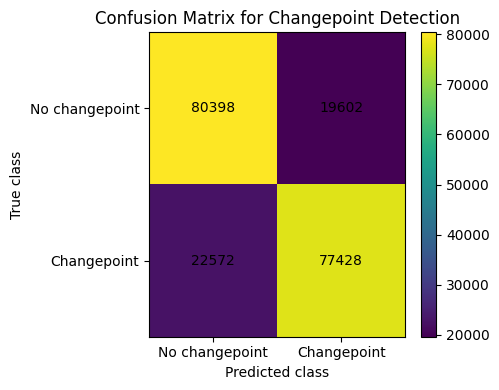

In [11]:

plt.figure(figsize=(5, 4))
plt.imshow(test_cm, aspect="auto")
plt.xticks([0, 1], ["No changepoint", "Changepoint"])
plt.yticks([0, 1], ["No changepoint", "Changepoint"])
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Confusion Matrix for Changepoint Detection")
for i in range(test_cm.shape[0]):
    for j in range(test_cm.shape[1]):
        plt.text(j, i, str(test_cm[i, j]), ha="center", va="center")
plt.colorbar()
plt.tight_layout()
save_current_figure("confusion_matrix_for_changepoint_detection.png")
plt.show()


## 10. Visualización del entrenamiento y del criterio de decisión

Las figuras de esta sección resumen la evolución de las pérdidas, las métricas de detección y el comportamiento de los umbrales evaluados durante la selección del criterio final.

Estas visualizaciones facilitan la identificación de sobreajuste, inestabilidad del entrenamiento o decisiones de umbral que favorecen de manera excesiva una de las dos clases.


Saved figure: C:\Users\chair\Downloads\changepoint_new_phase_files\model_outputs\convlstm_softonly_global_detection_localization_dx\figures\training_and_validation_loss.png


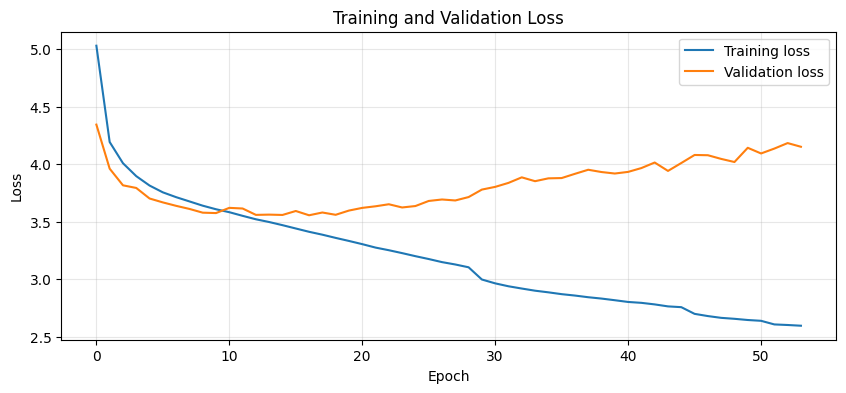

Saved figure: C:\Users\chair\Downloads\changepoint_new_phase_files\model_outputs\convlstm_softonly_global_detection_localization_dx\figures\detection_metrics_across_epochs.png


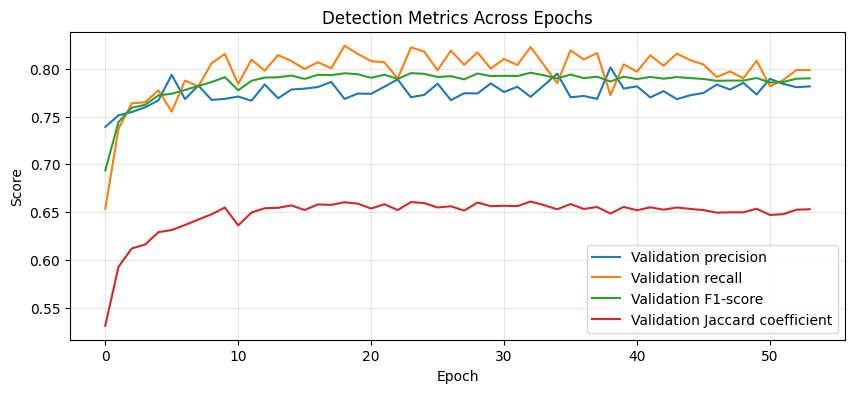

Saved figure: C:\Users\chair\Downloads\changepoint_new_phase_files\model_outputs\convlstm_softonly_global_detection_localization_dx\figures\threshold_comparison_for_changepoint_detection.png


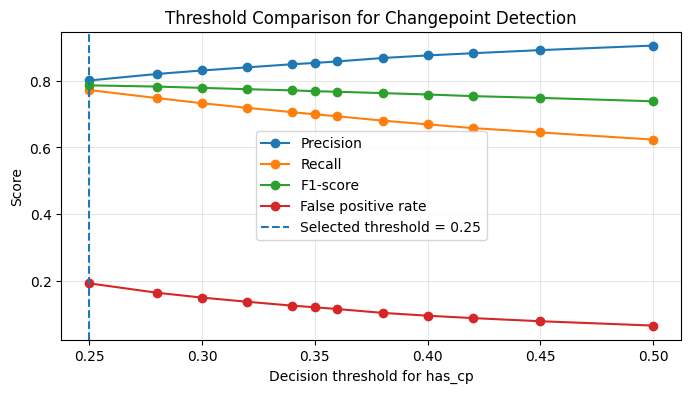

In [12]:

plt.figure(figsize=(10, 4))
plt.plot(history_frame["loss"], label="Training loss")
plt.plot(history_frame["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
save_current_figure("training_and_validation_loss.png")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(validation_metrics_frame["val_detection_precision"], label="Validation precision")
plt.plot(validation_metrics_frame["val_detection_recall"], label="Validation recall")
plt.plot(validation_metrics_frame["val_detection_f1"], label="Validation F1-score")
plt.plot(validation_metrics_frame["val_jaccard_coefficient"], label="Validation Jaccard coefficient")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Detection Metrics Across Epochs")
plt.legend()
plt.grid(alpha=0.3)
save_current_figure("detection_metrics_across_epochs.png")
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(validation_threshold_table["threshold"], validation_threshold_table["precision"], marker="o", label="Precision")
plt.plot(validation_threshold_table["threshold"], validation_threshold_table["recall"], marker="o", label="Recall")
plt.plot(validation_threshold_table["threshold"], validation_threshold_table["f1_score"], marker="o", label="F1-score")
plt.plot(validation_threshold_table["threshold"], validation_threshold_table["false_positive_rate"], marker="o", label="False positive rate")
plt.axvline(selected_threshold, linestyle="--", label=f"Selected threshold = {selected_threshold:.2f}")
plt.xlabel("Decision threshold for has_cp")
plt.ylabel("Score")
plt.title("Threshold Comparison for Changepoint Detection")
plt.legend()
plt.grid(alpha=0.3)
save_current_figure("threshold_comparison_for_changepoint_detection.png")
plt.show()


## 11. Análisis por tipo de transición

El análisis por transición descompone los resultados según el par de modelos de difusión que define cada trayectoria con punto de cambio. Esta evaluación permite identificar qué cambios dinámicos son detectados con mayor facilidad y cuáles presentan mayor dificultad para la localización temporal.

La información por transición complementa las métricas globales, ya que dos modelos con valores promedio similares pueden comportarse de forma distinta ante transiciones específicas.

In [13]:
test_pred_cp = soft_positions(test_cp_dist)

results_frame = test_metadata.copy()
results_frame["has_cp_prob"] = test_has_prob
results_frame["has_cp_pred"] = test_pred_has
results_frame["pred_cp"] = test_pred_cp

results_frame["abs_error"] = np.where(
    results_frame["has_changepoint"] == 1,
    np.abs(results_frame["pred_cp"] - results_frame["cp"]),
    np.nan,
)
results_frame["squared_error"] = np.where(
    results_frame["has_changepoint"] == 1,
    (results_frame["pred_cp"] - results_frame["cp"]) ** 2,
    np.nan,
)

transition_rows = []
with_cp = results_frame[results_frame["has_changepoint"] == 1].copy()


for transition in TRANSITION_ORDER:
    group = with_cp[with_cp["transition"] == transition].copy()
    if group.empty:
        continue
    tp_group = group[group["has_cp_pred"] == 1].copy()

    row = {
        "transition": transition,
        "model1": group["model1"].iloc[0],
        "model2": group["model2"].iloc[0],
        "n_examples": int(len(group)),
        "n_true_positives": int((group["has_cp_pred"] == 1).sum()),
        "n_false_negatives": int((group["has_cp_pred"] == 0).sum()),
        "detection_recall": float((group["has_cp_pred"] == 1).mean()),
        "false_negative_rate": float((group["has_cp_pred"] == 0).mean()),
        "mae_all": float(group["abs_error"].mean()),
        "rmse_all": float(np.sqrt(group["squared_error"].mean())),
        "mae_true_positive": float(tp_group["abs_error"].mean()) if len(tp_group) else np.nan,
        "rmse_true_positive": float(np.sqrt(tp_group["squared_error"].mean())) if len(tp_group) else np.nan,
    }

    transition_rows.append(row)

transition_metrics = pd.DataFrame(transition_rows)
transition_metrics.to_csv(OUTPUT_DIR / "transition_level_metrics.csv", index=False)
transition_metrics.sort_values("rmse_true_positive").head(10)

,transition,model1,model2,n_examples,n_true_positives,n_false_negatives,detection_recall,false_negative_rate,mae_all,rmse_all,mae_true_positive,rmse_true_positive
6,CTRW → LW,CTRW,LW,5000,4783,217,0.9566,0.0434,3.193987,6.701100,2.724434,5.794120
13,LW → CTRW,LW,CTRW,5000,4786,214,0.9572,0.0428,3.225046,6.675417,2.898709,6.138235
2,ATTM → LW,ATTM,LW,5000,4440,560,0.8880,0.1120,5.339216,9.444487,4.195534,7.680128
12,LW → ATTM,LW,ATTM,5000,4438,562,0.8876,0.1124,5.463565,9.582244,4.413760,8.140403
15,LW → SBM,LW,SBM,5000,4210,790,0.8420,0.1580,5.936200,10.125319,4.533368,8.255454
14,LW → FBM,LW,FBM,5000,4105,895,0.8210,0.1790,6.518754,11.018089,4.678734,8.527972
7,CTRW → SBM,CTRW,SBM,5000,4421,579,0.8842,0.1158,6.086038,10.089681,5.034432,8.649982
5,CTRW → FBM,CTRW,FBM,5000,4268,732,0.8536,0.1464,6.319046,10.445521,4.995230,8.690571
19,SBM → LW,SBM,LW,5000,4188,812,0.8376,0.1624,6.518403,10.633975,5.166156,8.870988
17,SBM → CTRW,SBM,CTRW,5000,4306,694,0.8612,0.1388,6.443645,10.236780,5.404187,8.885906


Saved figure: C:\Users\chair\Downloads\changepoint_new_phase_files\model_outputs\convlstm_softonly_global_detection_localization_dx\figures\detection_recall_by_transition.png


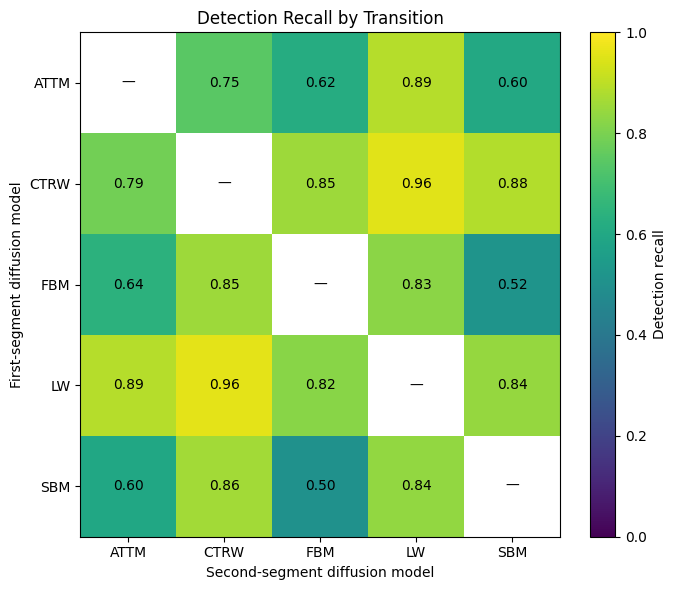

Saved figure: C:\Users\chair\Downloads\changepoint_new_phase_files\model_outputs\convlstm_softonly_global_detection_localization_dx\figures\localization_rmse_by_transition.png


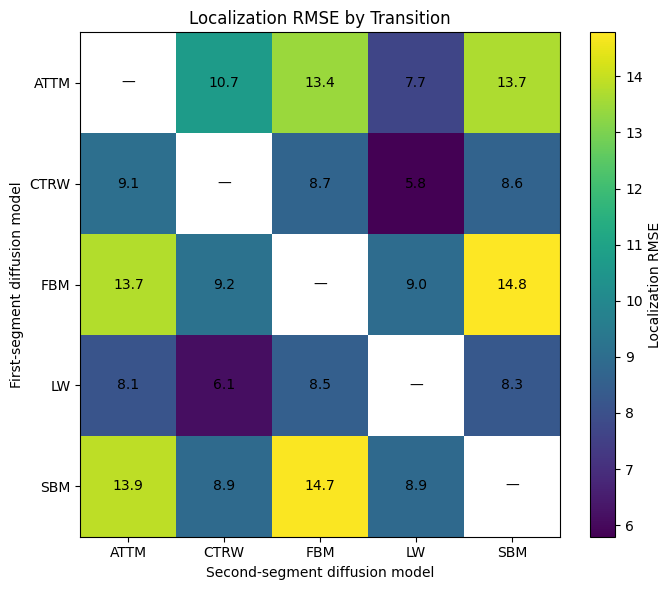

In [14]:
def transition_matrix(column):
    matrix = pd.DataFrame(np.nan, index=MODEL_NAMES, columns=MODEL_NAMES, dtype=float)
    for _, row in transition_metrics.iterrows():
        matrix.loc[row["model1"], row["model2"]] = row[column]
    return matrix


def plot_transition_matrix(matrix, title, colorbar_label, filename, value_format="{:.2f}", vmin=None, vmax=None):
    fig, ax = plt.subplots(figsize=(7, 6))
    image = ax.imshow(matrix.values, aspect="auto", vmin=vmin, vmax=vmax)
    ax.set_xticks(np.arange(len(MODEL_NAMES)))
    ax.set_yticks(np.arange(len(MODEL_NAMES)))
    ax.set_xticklabels(MODEL_NAMES)
    ax.set_yticklabels(MODEL_NAMES)
    ax.set_xlabel("Second-segment diffusion model")
    ax.set_ylabel("First-segment diffusion model")
    ax.set_title(title)

    for i in range(len(MODEL_NAMES)):
        for j in range(len(MODEL_NAMES)):
            value = matrix.iloc[i, j]
            text = "—" if np.isnan(value) else value_format.format(value)
            ax.text(j, i, text, ha="center", va="center")

    plt.colorbar(image, ax=ax, label=colorbar_label)
    plt.tight_layout()
    save_current_figure(filename)
    plt.show()


recall_matrix = transition_matrix("detection_recall")
fnr_matrix = transition_matrix("false_negative_rate")
rmse_matrix = transition_matrix("rmse_true_positive")

plot_transition_matrix(
    recall_matrix,
    "Detection Recall by Transition",
    "Detection recall",
    "detection_recall_by_transition.png",
    value_format="{:.2f}",
    vmin=0,
    vmax=1,
)

plot_transition_matrix(
    rmse_matrix,
    "Localization RMSE by Transition",
    "Localization RMSE",
    "localization_rmse_by_transition.png",
    value_format="{:.1f}",
)

## 12. Identificación de transiciones de distinta dificultad

Se construye una medida de dificultad que combina la tasa de falsos negativos y el error de localización. Las transiciones con baja frecuencia de detección o con errores temporales elevados reciben una puntuación de mayor dificultad.

Esta tabla sirve para seleccionar casos representativos en la inspección visual y para interpretar qué tipos de cambio son más exigentes para la arquitectura evaluada.

In [15]:
def minmax(series):
    series = series.astype(float)
    if series.max() == series.min():
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - series.min()) / (series.max() - series.min())


difficulty = transition_metrics.copy()
difficulty["rmse_for_score"] = difficulty["rmse_true_positive"].fillna(difficulty["rmse_all"])
difficulty["difficulty_score"] = minmax(difficulty["false_negative_rate"]) + minmax(difficulty["rmse_for_score"])

easy = difficulty.sort_values("difficulty_score").head(5).copy()
difficult = difficulty.sort_values("difficulty_score", ascending=False).head(5).copy()

easy["category"] = "Easy"
difficult["category"] = "Difficult"

easy_difficult = pd.concat([easy, difficult], ignore_index=True)
easy_difficult["interpretation"] = np.where(
    easy_difficult["category"] == "Easy",
    "High detection recall and low localization error.",
    "Low detection recall and/or high localization error.",
)

easy_difficult = easy_difficult[
    [
        "category",
        "transition",
        "detection_recall",
        "false_negative_rate",
        "mae_all",
        "rmse_all",
        "mae_true_positive",
        "rmse_true_positive",
        "interpretation",
    ]
]

easy_difficult.to_csv(OUTPUT_DIR / "easy_difficult_transitions.csv", index=False)
easy_difficult

,category,transition,detection_recall,false_negative_rate,mae_all,rmse_all,mae_true_positive,rmse_true_positive,interpretation
0,Easy,CTRW → LW,0.9566,0.0434,3.193987,6.701100,2.724434,5.794120,High detection recall and low localization error.
1,Easy,LW → CTRW,0.9572,0.0428,3.225046,6.675417,2.898709,6.138235,High detection recall and low localization error.
2,Easy,ATTM → LW,0.8880,0.1120,5.339216,9.444487,4.195534,7.680128,High detection recall and low localization error.
3,Easy,LW → ATTM,0.8876,0.1124,5.463565,9.582244,4.413760,8.140403,High detection recall and low localization error.
4,Easy,CTRW → SBM,0.8842,0.1158,6.086038,10.089681,5.034432,8.649982,High detection recall and low localization error.
5,Difficult,SBM → FBM,0.5048,0.4952,12.681910,15.997900,11.344999,14.717211,Low detection recall and/or high localization ...
6,Difficult,FBM → SBM,0.5180,0.4820,12.562643,15.931348,11.219584,14.783649,Low detection recall and/or high localization ...
7,Difficult,SBM → ATTM,0.5960,0.4040,11.131082,14.786884,9.961101,13.893056,Low detection recall and/or high localization ...
8,Difficult,ATTM → SBM,0.6026,0.3974,11.147481,15.099409,9.462858,13.660115,Low detection recall and/or high localization ...
9,Difficult,ATTM → FBM,0.6178,0.3822,11.269180,15.082561,9.363568,13.433691,Low detection recall and/or high localization ...


Saved figure: C:\Users\chair\Downloads\changepoint_new_phase_files\model_outputs\convlstm_softonly_global_detection_localization_dx\figures\transition_level_detection_localization_difficulty.png


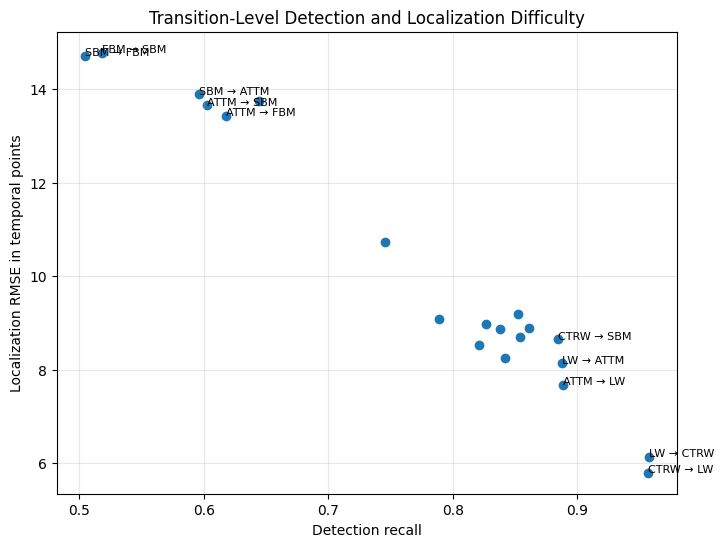

In [16]:

plot_data = difficulty.copy()
plt.figure(figsize=(8, 6))
plt.scatter(plot_data["detection_recall"], plot_data["rmse_for_score"])

for _, row in pd.concat([easy, difficult]).iterrows():
    plt.text(row["detection_recall"], row["rmse_for_score"], row["transition"], fontsize=8)

plt.xlabel("Detection recall")
plt.ylabel("Localization RMSE in temporal points")
plt.title("Transition-Level Detection and Localization Difficulty")
plt.grid(alpha=0.3)
save_current_figure("transition_level_detection_localization_difficulty.png")
plt.show()


## 13. Ejemplos representativos de trayectorias

Se muestran trayectorias asociadas a transiciones de distinta dificultad. En las trayectorias con punto de cambio, la línea de referencia indica la posición real y la predicción del modelo se obtiene a partir de la distribución temporal `cp_dist`.

Estos ejemplos permiten relacionar las métricas agregadas con patrones concretos observados en la serie de incrementos `dx(t)`.

Saved figure: C:\Users\chair\Downloads\changepoint_new_phase_files\model_outputs\convlstm_softonly_global_detection_localization_dx\figures\representative_trajectories_true_predicted_changepoints.png


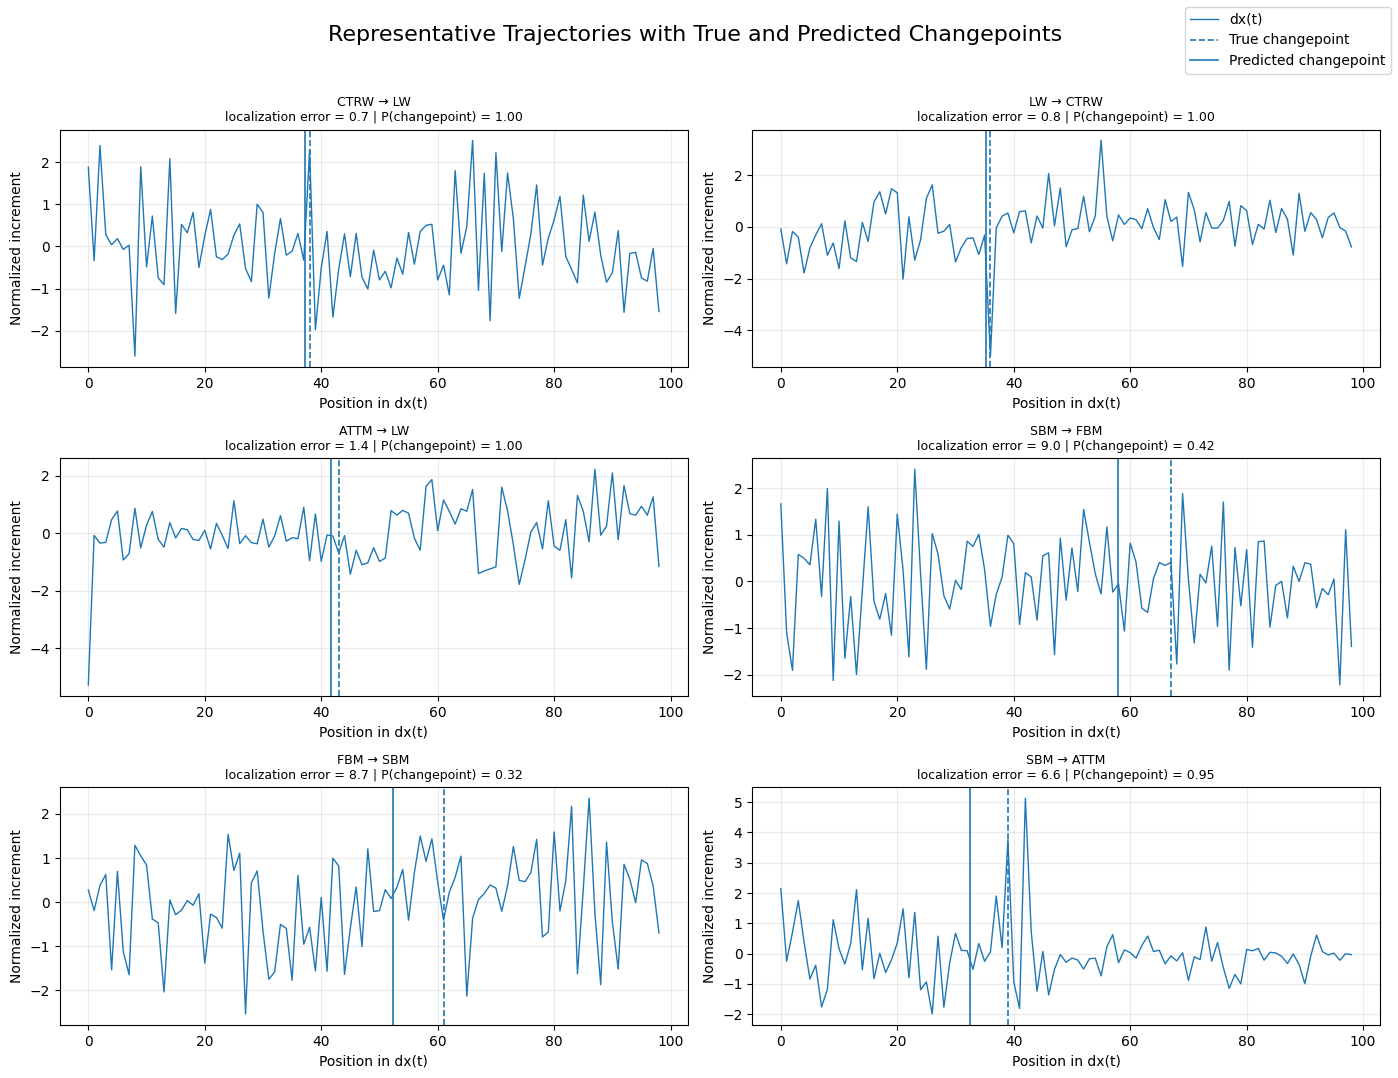

In [17]:
selected_transitions = easy["transition"].tolist()[:3] + difficult["transition"].tolist()[:3]
selected_indices = []

for transition in selected_transitions:
    group = results_frame[(results_frame["has_changepoint"] == 1) & (results_frame["transition"] == transition)].copy()
    tp_group = group[group["has_cp_pred"] == 1].copy()
    if len(tp_group):
        group = tp_group
    if len(group):
        median_error = group["abs_error"].median()
        selected_indices.append((group["abs_error"] - median_error).abs().idxmin())

n_cols = 2
n_rows = int(np.ceil(len(selected_indices) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.6 * n_rows), squeeze=False)
axes = axes.ravel()

for ax, idx in zip(axes, selected_indices):
    row = results_frame.loc[idx]
    ax.plot(x_test[idx, :, 0], linewidth=1.0, label="dx(t)")
    ax.axvline(row["cp_dx"], linestyle="--", linewidth=1.2, label="True changepoint")
    ax.axvline(row["pred_cp"] - 1.0, linestyle="-", linewidth=1.2, label="Predicted changepoint")
    ax.set_title(
        f"{row['transition']}\n"
        f"localization error = {row['abs_error']:.1f} | "
        f"P(changepoint) = {row['has_cp_prob']:.2f}",
        fontsize=9,
    )
    ax.set_xlabel("Position in dx(t)")
    ax.set_ylabel("Normalized increment")
    ax.grid(alpha=0.25)

for j in range(len(selected_indices), len(axes)):
    axes[j].axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
fig.suptitle("Representative Trajectories with True and Predicted Changepoints", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
save_current_figure("representative_trajectories_true_predicted_changepoints.png")
plt.show()

## 14. Evaluación complementaria del modelo

Las siguientes celdas utilizan las predicciones del mejor modelo guardado para analizar con mayor detalle el comportamiento del ConvLSTM. Se examinan los falsos negativos, los falsos positivos, los errores de localización por transición y la relación entre el rendimiento y la posición temporal real del punto de cambio.

Estas visualizaciones no alteran la arquitectura ni el procedimiento de entrenamiento; su función es ampliar la interpretación de los resultados obtenidos en el conjunto de test.

In [18]:

def build_transition_matrix(metric_name):
    matrix = pd.DataFrame(np.nan, index=MODEL_NAMES, columns=MODEL_NAMES, dtype=float)
    for _, row in transition_metrics.iterrows():
        matrix.loc[row["model1"], row["model2"]] = row[metric_name]
    return matrix


def save_matrix_csv(matrix, filename):
    path = OUTPUT_DIR / filename
    matrix.to_csv(path)
    return path


def plot_matrix(matrix, title, colorbar_label, filename, value_format="{:.2f}", vmin=None, vmax=None):
    fig, ax = plt.subplots(figsize=(7, 6))
    image = ax.imshow(matrix.values, aspect="auto", vmin=vmin, vmax=vmax)
    ax.set_xticks(np.arange(len(MODEL_NAMES)))
    ax.set_yticks(np.arange(len(MODEL_NAMES)))
    ax.set_xticklabels(MODEL_NAMES)
    ax.set_yticklabels(MODEL_NAMES)
    ax.set_xlabel("Second-segment diffusion model")
    ax.set_ylabel("First-segment diffusion model")
    ax.set_title(title)

    for i in range(len(MODEL_NAMES)):
        for j in range(len(MODEL_NAMES)):
            value = matrix.iloc[i, j]
            text = "—" if np.isnan(value) else value_format.format(value)
            ax.text(j, i, text, ha="center", va="center")

    plt.colorbar(image, ax=ax, label=colorbar_label)
    plt.tight_layout()
    save_current_figure(filename)
    plt.show()


### 14.1 Tasa de falsos negativos por transición

Esta matriz muestra, para cada transición real, la proporción de trayectorias con punto de cambio que fueron clasificadas como trayectorias sin punto de cambio. Los valores altos indican transiciones que el modelo tiende a no detectar.

El análisis permite distinguir errores de detección asociados a pares específicos de modelos de difusión.

Saved figure: C:\Users\chair\Downloads\changepoint_new_phase_files\model_outputs\convlstm_softonly_global_detection_localization_dx\figures\false_negative_rate_by_transition.png


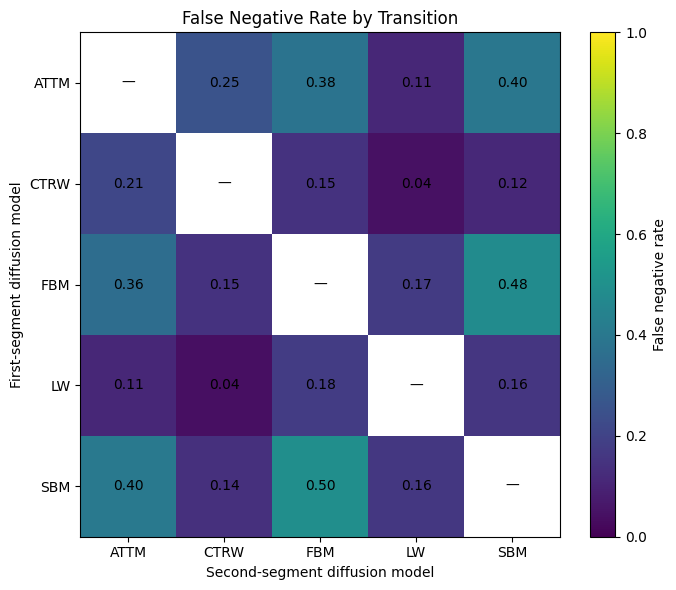

,ATTM,CTRW,FBM,LW,SBM
ATTM,NaN,0.2546,0.3822,0.1120,0.3974
CTRW,0.2110,NaN,0.1464,0.0434,0.1158
FBM,0.3558,0.1478,NaN,0.1734,0.4820
LW,0.1124,0.0428,0.1790,NaN,0.1580
SBM,0.4040,0.1388,0.4952,0.1624,NaN


In [19]:

false_negative_matrix = build_transition_matrix("false_negative_rate")
save_matrix_csv(false_negative_matrix, "false_negative_rate_by_transition.csv")

plot_matrix(
    false_negative_matrix,
    "False Negative Rate by Transition",
    "False negative rate",
    "false_negative_rate_by_transition.png",
    value_format="{:.2f}",
    vmin=0,
    vmax=1,
)

false_negative_matrix


### 14.2 Tasa de falsos positivos en trayectorias sin punto de cambio

Esta tabla y su visualización resumen qué modelos homogéneos generan con mayor frecuencia predicciones incorrectas de presencia de punto de cambio.

El resultado es útil para evaluar si ciertos regímenes de difusión anómala, aun sin transición real, producen fluctuaciones que el modelo interpreta como indicios de cambio.

Saved figure: C:\Users\chair\Downloads\changepoint_new_phase_files\model_outputs\convlstm_softonly_global_detection_localization_dx\figures\false_positive_rate_by_no_changepoint_model.png


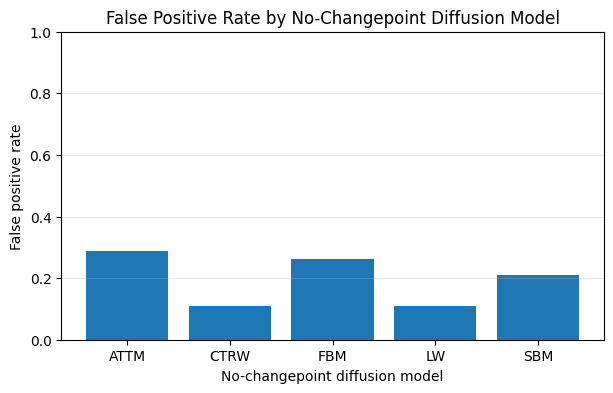

,diffusion_model,total_no_changepoint,false_positives,false_positive_rate
0,ATTM,20000,5784,0.28920
1,CTRW,20000,2165,0.10825
2,FBM,20000,5226,0.26130
3,LW,20000,2209,0.11045
4,SBM,20000,4218,0.21090


In [20]:

no_changepoint_results = results_frame[results_frame["has_changepoint"] == 0].copy()

false_positive_by_model = (
    no_changepoint_results
    .groupby("model1")
    .agg(
        total_no_changepoint=("has_cp_pred", "size"),
        false_positives=("has_cp_pred", "sum"),
        false_positive_rate=("has_cp_pred", "mean"),
    )
    .reindex(MODEL_NAMES)
    .reset_index()
    .rename(columns={"model1": "diffusion_model"})
)

false_positive_by_model.to_csv(OUTPUT_DIR / "false_positive_rate_by_no_changepoint_model.csv", index=False)

plt.figure(figsize=(7, 4))
plt.bar(false_positive_by_model["diffusion_model"], false_positive_by_model["false_positive_rate"])
plt.ylim(0, 1)
plt.xlabel("No-changepoint diffusion model")
plt.ylabel("False positive rate")
plt.title("False Positive Rate by No-Changepoint Diffusion Model")
plt.grid(axis="y", alpha=0.3)
save_current_figure("false_positive_rate_by_no_changepoint_model.png")
plt.show()

false_positive_by_model


### 14.3 Errores MAE y RMSE de localización por transición

Se comparan el error absoluto medio (`MAE`) y la raíz del error cuadrático medio (`RMSE`) para cada transición con punto de cambio. El `MAE` resume el error típico, mientras que el `RMSE` aumenta cuando existen errores temporales especialmente grandes.

La comparación entre ambas métricas ayuda a identificar transiciones con localización globalmente aceptable pero con fallos puntuales relevantes.

Saved figure: C:\Users\chair\Downloads\changepoint_new_phase_files\model_outputs\convlstm_softonly_global_detection_localization_dx\figures\localization_mae_by_transition.png


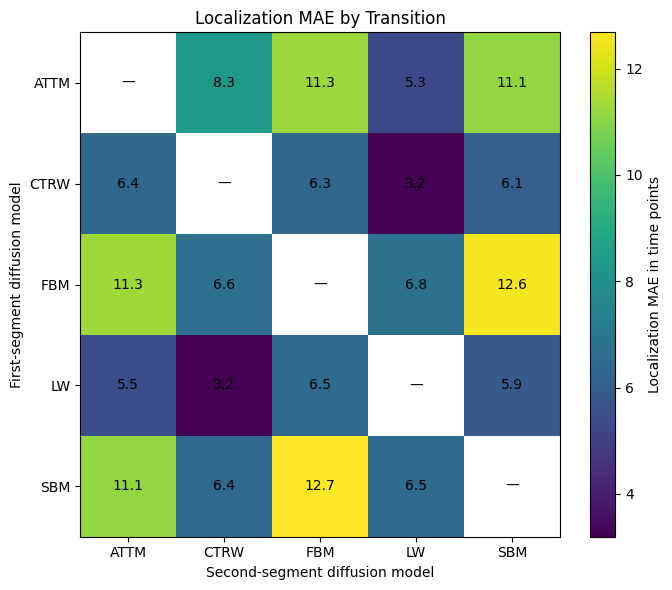

Saved figure: C:\Users\chair\Downloads\changepoint_new_phase_files\model_outputs\convlstm_softonly_global_detection_localization_dx\figures\localization_rmse_by_transition.png


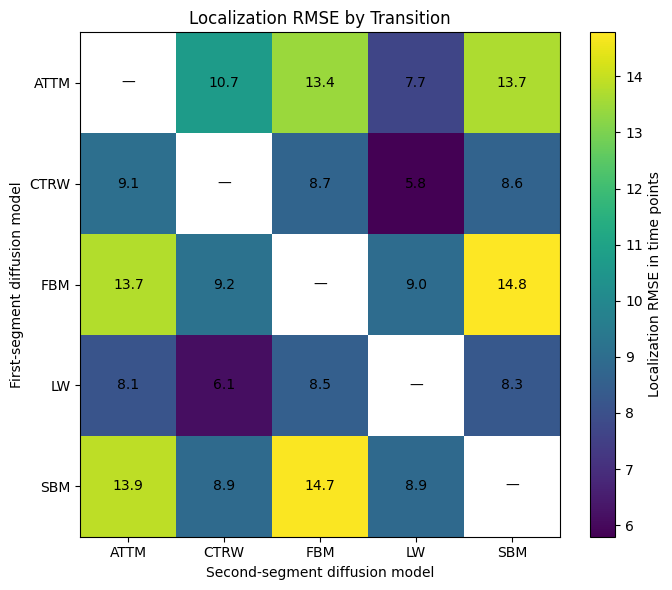

,ATTM,CTRW,FBM,LW,SBM
ATTM,NaN,8.308004,11.269180,5.339216,11.147481
CTRW,6.399115,NaN,6.319046,3.193987,6.086038
FBM,11.342917,6.645937,NaN,6.757437,12.562643
LW,5.463565,3.225046,6.518754,NaN,5.936200
SBM,11.131082,6.443645,12.681910,6.518403,NaN


In [21]:
mae_transition_matrix = build_transition_matrix("mae_all")
rmse_transition_matrix = build_transition_matrix("rmse_true_positive")

save_matrix_csv(mae_transition_matrix, "localization_mae_by_transition.csv")
save_matrix_csv(rmse_transition_matrix, "localization_rmse_by_transition.csv")

plot_matrix(
    mae_transition_matrix,
    "Localization MAE by Transition",
    "Localization MAE in time points",
    "localization_mae_by_transition.png",
    value_format="{:.1f}",
)

plot_matrix(
    rmse_transition_matrix,
    "Localization RMSE by Transition",
    "Localization RMSE in time points",
    "localization_rmse_by_transition.png",
    value_format="{:.1f}",
)

mae_transition_matrix

### 14.4 Ordenación de transiciones según dificultad

La ordenación combina la tasa de falsos negativos con el error de localización para establecer una clasificación relativa de las transiciones. Las transiciones más favorables presentan alta capacidad de detección y bajo error temporal; las más difíciles combinan baja sensibilidad, mala localización o ambas características.

Esta clasificación facilita la comparación metodológica entre arquitecturas y la selección de ejemplos representativos para el análisis cualitativo.

Saved figure: C:\Users\chair\Downloads\changepoint_new_phase_files\model_outputs\convlstm_softonly_global_detection_localization_dx\figures\transition_difficulty_ranking.png


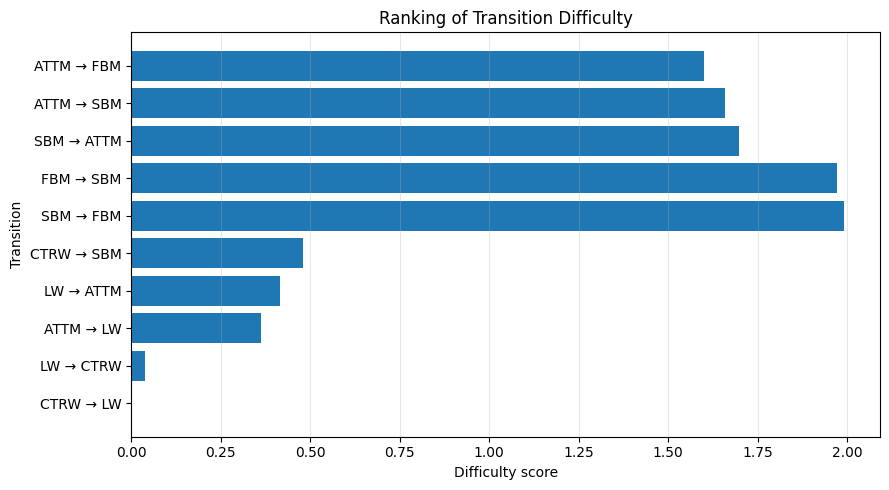

Top 5 easiest transitions


,rank,transition,detection_recall,false_negative_rate,localization_mae,localization_rmse,difficulty_score,interpretation
0,1,CTRW → LW,0.9566,0.0434,2.724434,5.794120,0.001326,Easy transition: high detection recall and low...
1,2,LW → CTRW,0.9572,0.0428,2.898709,6.138235,0.038280,Easy transition: high detection recall and low...
2,3,ATTM → LW,0.8880,0.1120,4.195534,7.680128,0.362763,Easy transition: high detection recall and low...
3,4,LW → ATTM,0.8876,0.1124,4.413760,8.140403,0.414848,Easy transition: high detection recall and low...
4,5,CTRW → SBM,0.8842,0.1158,5.034432,8.649982,0.479049,Easy transition: high detection recall and low...


Top 5 most difficult transitions


,rank,transition,detection_recall,false_negative_rate,localization_mae,localization_rmse,difficulty_score,interpretation
19,20,SBM → FBM,0.5048,0.4952,11.344999,14.717211,1.992609,Difficult transition: low detection recall and...
18,19,FBM → SBM,0.5180,0.4820,11.219584,14.783649,1.970822,Difficult transition: low detection recall and...
17,18,SBM → ATTM,0.5960,0.4040,9.961101,13.893056,1.699338,Difficult transition: low detection recall and...
16,17,ATTM → SBM,0.6026,0.3974,9.462858,13.660115,1.658837,Difficult transition: low detection recall and...
15,16,ATTM → FBM,0.6178,0.3822,9.363568,13.433691,1.600051,Difficult transition: low detection recall and...


In [22]:
transition_ranking = transition_metrics.copy()
transition_ranking["localization_rmse"] = transition_ranking["rmse_true_positive"].fillna(transition_ranking["rmse_all"])
transition_ranking["localization_mae"] = transition_ranking["mae_true_positive"].fillna(transition_ranking["mae_all"])


def normalized_series(values):
    values = values.astype(float)
    if values.max() == values.min():
        return pd.Series(np.zeros(len(values)), index=values.index)
    return (values - values.min()) / (values.max() - values.min())


transition_ranking["normalized_false_negative_rate"] = normalized_series(transition_ranking["false_negative_rate"])
transition_ranking["normalized_localization_rmse"] = normalized_series(transition_ranking["localization_rmse"])
transition_ranking["difficulty_score"] = (
    transition_ranking["normalized_false_negative_rate"] +
    transition_ranking["normalized_localization_rmse"]
)

ranked_transitions = transition_ranking.sort_values("difficulty_score").reset_index(drop=True)
ranked_transitions["rank"] = np.arange(1, len(ranked_transitions) + 1)
ranked_transitions["interpretation"] = np.where(
    ranked_transitions["rank"] <= 5,
    "Easy transition: high detection recall and low localization error.",
    np.where(
        ranked_transitions["rank"] > len(ranked_transitions) - 5,
        "Difficult transition: low detection recall and/or high localization error.",
        "Intermediate transition."
    )
)

transition_difficulty_ranking = ranked_transitions[
    [
        "rank",
        "transition",
        "detection_recall",
        "false_negative_rate",
        "localization_mae",
        "localization_rmse",
        "difficulty_score",
        "interpretation",
    ]
]

transition_difficulty_ranking.to_csv(OUTPUT_DIR / "transition_difficulty_ranking.csv", index=False)

top_easiest = transition_difficulty_ranking.head(5)
top_difficult = transition_difficulty_ranking.tail(5).sort_values("difficulty_score", ascending=False)

plt.figure(figsize=(9, 5))
plot_table = pd.concat([top_easiest, top_difficult])
plt.barh(plot_table["transition"], plot_table["difficulty_score"])
plt.xlabel("Difficulty score")
plt.ylabel("Transition")
plt.title("Ranking of Transition Difficulty")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
save_current_figure("transition_difficulty_ranking.png")
plt.show()

print("Top 5 easiest transitions")
display(top_easiest)

print("Top 5 most difficult transitions")
display(top_difficult)

### 14.5 Error de localización según intervalo temporal del punto de cambio

Las trayectorias se agrupan según la posición real del punto de cambio. Esta evaluación permite comprobar si el modelo localiza con mayor precisión las transiciones situadas en la zona central de la trayectoria o si el error aumenta cerca de los extremos del intervalo permitido.

El análisis es relevante porque la cantidad de información disponible antes y después del cambio puede influir en la localización temporal.

Saved figure: C:\Users\chair\Downloads\changepoint_new_phase_files\model_outputs\convlstm_softonly_global_detection_localization_dx\figures\performance_by_true_changepoint_interval.png


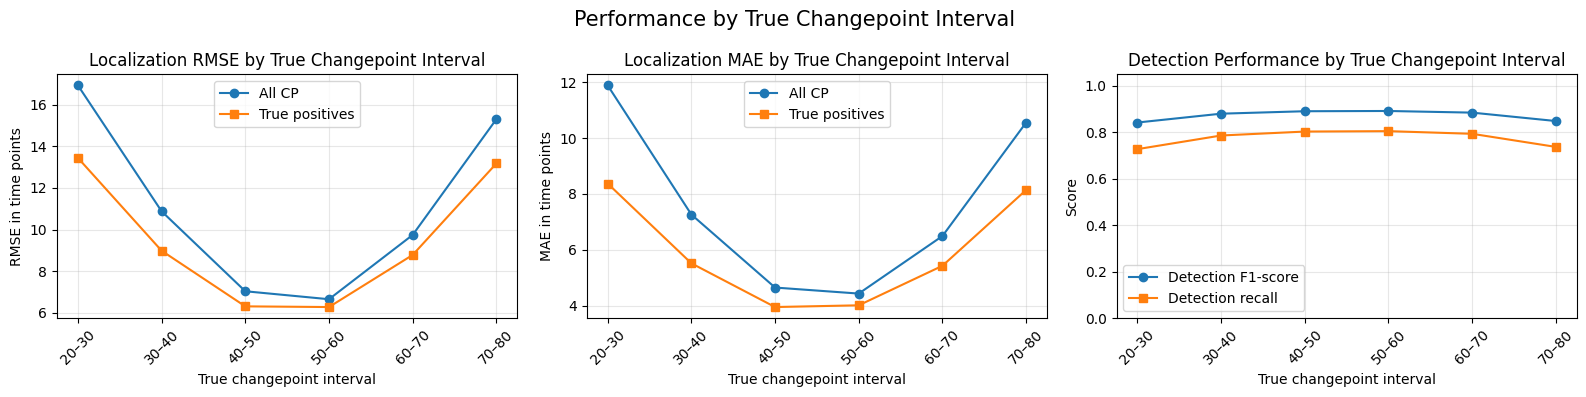

,true_changepoint_interval,number_of_examples,detection_recall,detection_f1_score,localization_mae,localization_rmse,localization_mae_true_positive,localization_rmse_true_positive
0,20–30,16516,0.727840,0.842485,11.886609,16.916656,8.373668,13.436825
1,30–40,16224,0.786551,0.880524,7.263655,10.875662,5.517941,8.983885
2,40–50,16319,0.803542,0.891071,4.650354,7.040482,3.952429,6.315876
3,50–60,16436,0.805305,0.892154,4.434515,6.658241,4.014394,6.283034
4,60–70,16482,0.793836,0.885071,6.494087,9.742821,5.429013,8.782836
5,70–80,16327,0.737429,0.848874,10.556506,15.294964,8.142702,13.170741


In [23]:
changepoint_results = results_frame[results_frame["has_changepoint"] == 1].copy()

min_cp = int(np.floor(changepoint_results["cp"].min() / 10) * 10)
max_cp = int(np.ceil(changepoint_results["cp"].max() / 10) * 10)
bins = np.arange(min_cp, max_cp + 10, 10)

if len(bins) < 3:
    bins = np.linspace(changepoint_results["cp"].min(), changepoint_results["cp"].max() + 1, 4)

labels = [f"{int(bins[i])}–{int(bins[i+1])}" for i in range(len(bins) - 1)]
changepoint_results["cp_interval"] = pd.cut(
    changepoint_results["cp"],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=False,
)

interval_rows = []

for interval, group in changepoint_results.groupby("cp_interval", observed=False):
    if len(group) == 0:
        continue

    tp_group = group[group["has_cp_pred"] == 1]
    y_true_interval = np.ones(len(group), dtype=int)
    y_pred_interval = group["has_cp_pred"].to_numpy(dtype=int)

    interval_rows.append({
        "true_changepoint_interval": str(interval),
        "number_of_examples": int(len(group)),
        "detection_recall": float(group["has_cp_pred"].mean()),
        "detection_f1_score": float(f1_score(y_true_interval, y_pred_interval, zero_division=0)),
        "localization_mae": float(group["abs_error"].mean()),
        "localization_rmse": float(np.sqrt(group["squared_error"].mean())),
        "localization_mae_true_positive": float(tp_group["abs_error"].mean()) if len(tp_group) else np.nan,
        "localization_rmse_true_positive": float(np.sqrt(tp_group["squared_error"].mean())) if len(tp_group) else np.nan,
    })

interval_performance = pd.DataFrame(interval_rows)
interval_performance.to_csv(OUTPUT_DIR / "changepoint_interval_performance.csv", index=False)

x_positions = np.arange(len(interval_performance))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(x_positions, interval_performance["localization_rmse"], marker="o", label="All CP")
axes[0].plot(x_positions, interval_performance["localization_rmse_true_positive"], marker="s", label="True positives")
axes[0].set_title("Localization RMSE by True Changepoint Interval")
axes[0].set_xlabel("True changepoint interval")
axes[0].set_ylabel("RMSE in time points")
axes[0].set_xticks(x_positions)
axes[0].set_xticklabels(interval_performance["true_changepoint_interval"], rotation=45)
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(x_positions, interval_performance["localization_mae"], marker="o", label="All CP")
axes[1].plot(x_positions, interval_performance["localization_mae_true_positive"], marker="s", label="True positives")
axes[1].set_title("Localization MAE by True Changepoint Interval")
axes[1].set_xlabel("True changepoint interval")
axes[1].set_ylabel("MAE in time points")
axes[1].set_xticks(x_positions)
axes[1].set_xticklabels(interval_performance["true_changepoint_interval"], rotation=45)
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(x_positions, interval_performance["detection_f1_score"], marker="o", label="Detection F1-score")
axes[2].plot(x_positions, interval_performance["detection_recall"], marker="s", label="Detection recall")
axes[2].set_title("Detection Performance by True Changepoint Interval")
axes[2].set_xlabel("True changepoint interval")
axes[2].set_ylabel("Score")
axes[2].set_ylim(0, 1.05)
axes[2].set_xticks(x_positions)
axes[2].set_xticklabels(interval_performance["true_changepoint_interval"], rotation=45)
axes[2].legend()
axes[2].grid(alpha=0.3)

fig.suptitle("Performance by True Changepoint Interval", fontsize=15)
plt.tight_layout()
save_current_figure("performance_by_true_changepoint_interval.png")
plt.show()

interval_performance

### 14.6 Relación entre MAE y RMSE por transición

Esta figura compara `MAE` y `RMSE` para cada transición. Cuando el `RMSE` supera claramente al `MAE`, la transición puede presentar algunos errores de localización de gran magnitud aunque el error absoluto promedio sea moderado.

La relación entre ambas métricas permite diferenciar errores sistemáticos de errores aislados pero importantes.

Saved figure: C:\Users\chair\Downloads\changepoint_new_phase_files\model_outputs\convlstm_softonly_global_detection_localization_dx\figures\mae_rmse_relationship_by_transition.png


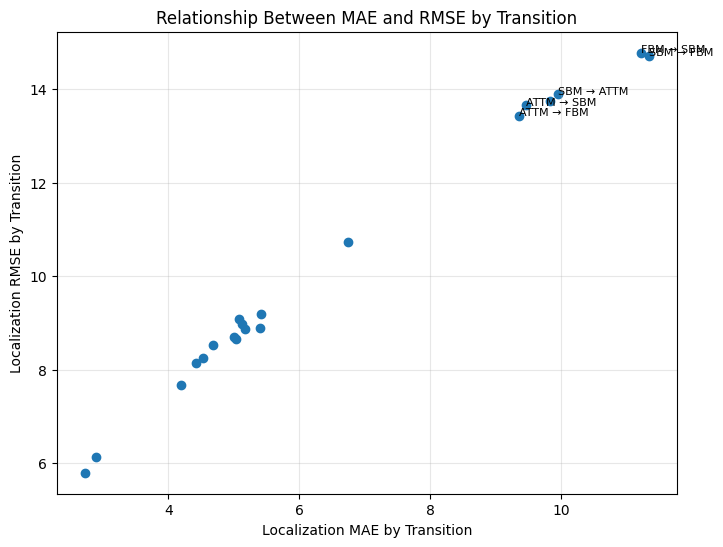

In [24]:
relationship_data = transition_metrics.copy()
relationship_data["relationship_mae"] = relationship_data["mae_true_positive"].fillna(relationship_data["mae_all"])
relationship_data["relationship_rmse"] = relationship_data["rmse_true_positive"].fillna(relationship_data["rmse_all"])

plt.figure(figsize=(8, 6))
plt.scatter(relationship_data["relationship_mae"], relationship_data["relationship_rmse"])

for _, row in top_difficult.iterrows():
    transition_name = row["transition"]
    point = relationship_data[relationship_data["transition"] == transition_name].iloc[0]
    plt.text(point["relationship_mae"], point["relationship_rmse"], transition_name, fontsize=8)

plt.xlabel("Localization MAE by Transition")
plt.ylabel("Localization RMSE by Transition")
plt.title("Relationship Between MAE and RMSE by Transition")
plt.grid(alpha=0.3)
save_current_figure("mae_rmse_relationship_by_transition.png")
plt.show()

### 14.7 Rendimiento en función de la posición temporal del punto de cambio

Esta visualización resume cómo varía el rendimiento cuando el punto de cambio aparece en distintas zonas temporales de la trayectoria. El objetivo es identificar posibles dependencias entre la posición real del cambio y la capacidad del modelo para detectarlo o localizarlo.

Una dependencia marcada indicaría que el modelo no aprovecha de forma uniforme la información disponible en toda la secuencia.

Saved figure: C:\Users\chair\Downloads\changepoint_new_phase_files\model_outputs\convlstm_softonly_global_detection_localization_dx\figures\changepoint_position_dependent_performance.png


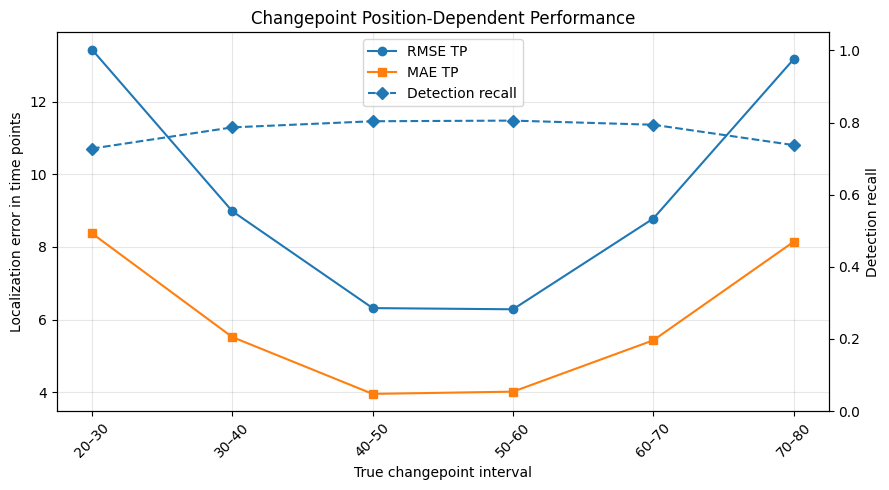

In [25]:
fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.plot(
    interval_performance["true_changepoint_interval"],
    interval_performance["localization_rmse_true_positive"],
    marker="o",
    label="RMSE TP",
)
ax1.plot(
    interval_performance["true_changepoint_interval"],
    interval_performance["localization_mae_true_positive"],
    marker="s",
    label="MAE TP",
)
ax1.set_xlabel("True changepoint interval")
ax1.set_ylabel("Localization error in time points")
ax1.tick_params(axis="x", rotation=45)
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(
    interval_performance["true_changepoint_interval"],
    interval_performance["detection_recall"],
    marker="D",
    linestyle="--",
    label="Detection recall",
)
ax2.set_ylabel("Detection recall")
ax2.set_ylim(0, 1.05)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper center")

plt.title("Changepoint Position-Dependent Performance")
plt.tight_layout()
save_current_figure("changepoint_position_dependent_performance.png")
plt.show()

### 14.8 Interpretación intermedia de la evaluación complementaria

Los análisis complementarios permiten examinar el rendimiento del modelo ConvLSTM con un nivel de detalle mayor que el proporcionado por las métricas globales. La tasa de falsos negativos muestra qué transiciones reales son más difíciles de reconocer, mientras que la tasa de falsos positivos permite estudiar qué trayectorias homogéneas se confunden con cambios de régimen.

El estudio de `MAE`, `RMSE` y posición temporal del punto de cambio ayuda a separar los errores de detección de los errores de localización. Esta sección funciona como apoyo interpretativo para los resultados finales, sin actuar como conclusión general del cuaderno.

## Resumen final

En este cuaderno se evaluó un modelo ConvLSTM para detección binaria y localización temporal en trayectorias con y sin punto de cambio, utilizando como entrada la serie de incrementos `dx(t)`. El umbral seleccionado fue `0.25`.

En el conjunto de test, el modelo alcanzó una `accuracy` de `0.789130`, una `precision` de `0.797980`, un `recall` de `0.774280`, un `F1-score` de `0.785951`, un `FPR` de `0.196020` y un `FNR` de `0.225720`.

Para la localización temporal, considerando todas las trayectorias con punto de cambio, el `MAE` fue `7.664480` y el `RMSE` fue `11.918347`. Entre las trayectorias correctamente detectadas como positivas, el `MAE` fue `5.913591` y el `RMSE` fue `9.951909`.

Estos resultados resumen el comportamiento del modelo ConvLSTM en la detección de puntos de cambio y en la estimación de su posición temporal.

In [26]:

final_summary = {
    "mode": "FAST_RUN" if FAST_RUN else "GLOBAL_RUN",
    "model_family": "ConvLSTM_1D_soft_position_only",
    "train_samples": int(x_train.shape[0]),
    "validation_samples": int(x_val.shape[0]),
    "test_samples": int(x_test.shape[0]),
    "selected_threshold": selected_threshold,
    "loss_weights": LOSS_WEIGHTS,
    "negative_class_weight": NEGATIVE_CLASS_WEIGHT,
    "positive_class_weight": POSITIVE_CLASS_WEIGHT,
    "thresholds": THRESHOLDS.tolist(),
    "global_test_summary": global_summary.to_dict(orient="records"),
    "output_dir": str(OUTPUT_DIR),
}

with open(OUTPUT_DIR / "final_summary_convlstm_softonly_detection_localization_dx.json", "w", encoding="utf-8") as file:
    json.dump(final_summary, file, indent=2, ensure_ascii=False)

best_model.save(OUTPUT_DIR / "convlstm_softonly_detection_localization_dx_best_model.keras")

print("Evaluation outputs saved in:", OUTPUT_DIR)
print("Figures saved in:", FIGURES_DIR)


Evaluation outputs saved in: C:\Users\chair\Downloads\changepoint_new_phase_files\model_outputs\convlstm_softonly_global_detection_localization_dx
Figures saved in: C:\Users\chair\Downloads\changepoint_new_phase_files\model_outputs\convlstm_softonly_global_detection_localization_dx\figures
